# Step 1: Geocode Schools with Google Maps API

In [ ]:
#Cell 1: install libraries
!pip install requests pandas
!pip install pyodbc pandas
!sudo apt-get install -y mdbtools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.3/340.3 kB 8.3 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libmdb3 libmdbsql3
Suggested packages:
  bash-completion
The following NEW packages will be installed:
  libmdb3 libmdbsql3 mdbtools
0 upgraded, 3 newly installed, 0 to remove and 3 not upgraded.
Need to get 136 kB of archives.
After this operation, 486 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libmdb3 amd64 1.0.0+dfsg-1 [68.9 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libmdbsql3 amd64 1.0.0+dfsg-1 [18.8 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 mdbtools amd64 1.0.0+dfsg-1 [48.3 kB]
Fetched 136 kB in 1s (157 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used.

In [ ]:
#Cell 2: mount the file location
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ---- Path configuration ----
# Change BASE_DIR if your Google Drive folder has a different name or
# location; every other path below is derived from it. This block is
# repeated once per Step (rather than defined only at the top of the
# notebook) so that each Step can still be run on its own in a fresh
# runtime without needing every earlier Step to have executed first.
#
# Expected folder layout under BASE_DIR (see data/README.md for the raw
# data sources that populate Raw_Data/ and Schools_Data/School_District_Boundaries/):
#   Raw_Data/                          raw NYSED .accdb/.mdb exports, raw HUD LIHTC.csv
#   Schools_Data/                      cleaned/intermediate school-level files
#     School_District_Boundaries/      NY public school district shapefile
#     Enrollment/                      raw enrollment source files
#     Attendance/                      raw attendance/suspension source files
#     Subgroups/                       per-demographic-subgroup collapsed files
#   LIHTC_Data/                        cleaned/intermediate LIHTC development files
#   api_key.txt                        Google Maps geocoding API key (plain text,
#                                       first line only) -- NEVER commit this file;
#                                       keep it in Drive only.

BASE_DIR = "/content/drive/MyDrive/LIHTCs_and_Schools/"

RAW_DIR = BASE_DIR + "Raw_Data/"
SCHOOLS_DIR = BASE_DIR + "Schools_Data/"
LIHTC_DIR = BASE_DIR + "LIHTC_Data/"
ENROLLMENT_DIR = SCHOOLS_DIR + "Enrollment/"
ATTENDANCE_DIR = SCHOOLS_DIR + "Attendance/"
SUBGROUPS_DIR = SCHOOLS_DIR + "Subgroups/"
DISTRICT_SHP = SCHOOLS_DIR + "School_District_Boundaries/New_York_State_Public_School_District_Boundaries.shp"
API_KEY_PATH = BASE_DIR + "api_key.txt"


In [ ]:
#Cell 3: load in datafiles

import glob

access_folder = RAW_DIR
files = glob.glob(access_folder + "*.accdb") + glob.glob(access_folder + "*.mdb")
files #lists filenames

['/content/drive/MyDrive/LIHTCs_and_Schools/Raw_Data/Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2017.accdb',
 '/content/drive/MyDrive/LIHTCs_and_Schools/Raw_Data/Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2018.accdb',
 '/content/drive/MyDrive/LIHTCs_and_Schools/Raw_Data/Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2016.accdb',
 '/content/drive/MyDrive/LIHTCs_and_Schools/Raw_Data/Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2015.accdb',
 '/content/drive/MyDrive/LIHTCs_and_Schools/Raw_Data/Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2019.accdb',
 '/content/drive/MyDrive/LIHTCs_and_Schools/Raw_Data/Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2014.mdb']

In [ ]:
#Cell 4: get table names:

import subprocess

for f in files:
  print("FILE", f)
  out = subprocess.check_output(["mdb-tables","-1",f]).decode()
  print(out)

FILE /content/drive/MyDrive/LIHTCs_and_Schools/Raw_Data/Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2017.accdb
3-8_ELA_AND_MATH_REPORT_2017

FILE /content/drive/MyDrive/LIHTCs_and_Schools/Raw_Data/Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2018.accdb
3-8_ELA_AND_MATH_REPORT_2018

FILE /content/drive/MyDrive/LIHTCs_and_Schools/Raw_Data/Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2016.accdb
3-8_ELA_AND_MATH_REPORT_2016

FILE /content/drive/MyDrive/LIHTCs_and_Schools/Raw_Data/Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2015.accdb
3-8_ELA_AND_MATH_REPORT_FOR_RELEASE

FILE /content/drive/MyDrive/LIHTCs_and_Schools/Raw_Data/Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2019.accdb
3-8_ELA_AND_MATH_REPORT_2019

FILE /content/drive/MyDrive/LIHTCs_and_Schools/Raw_Data/Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2014.mdb
3-8_ELA_AND_MATH_REPORT_FOR_RELEASE_2013
3-8_ELA_AND_MATH_REPORT_FOR_RELEASE_2014



In [ ]:
#Cell 5:Extract all 3-8 ELA/Math report tables to per-year CSVs
import re
import subprocess
import io
import glob
import pandas as pd

access_folder = RAW_DIR
output_dir = SCHOOLS_DIR

# Re-glob the source files here instead of relying on the `files` variable
# from cell 3 -- that name gets reassigned later (cell 6 reuses `files` for
# a list of CSVs), so depending on it makes this cell's behavior depend on
# execution order rather than being self-contained.
db_files = glob.glob(access_folder + "*.accdb") + glob.glob(access_folder + "*.mdb")

table_pattern = re.compile(r"3-8_ELA_AND_MATH_REPORT", re.IGNORECASE)
year_in_table = re.compile(r"(20\d{2})$")
year_in_filename = re.compile(r"(20\d{2})")

extracted_years = []

for f in db_files:
    tables = subprocess.check_output(["mdb-tables", "-1", f]).decode().split()
    candidate_tables = [t for t in tables if table_pattern.search(t)]

    if not candidate_tables:
        print(f"WARNING: no ELA/Math table found in {f} -- skipping")
        continue

    for table_name in candidate_tables:
        match = year_in_table.search(table_name)
        if match:
            year = match.group(1)
        else:
            fname_match = year_in_filename.search(f)
            if not fname_match:
                print(f"WARNING: could not determine year for table {table_name} in {f} -- skipping")
                continue
            year = fname_match.group(1)

        raw = subprocess.check_output(["mdb-export", f, table_name])
        df = pd.read_csv(io.BytesIO(raw))

        out_path = f"{output_dir}3-8_ELA_AND_MATH_REPORT_{year}.csv"
        df.to_csv(out_path, index=False)
        extracted_years.append(year)
        print(f"Extracted {table_name} from {f.split('/')[-1]} -> {out_path} ({len(df):,} rows)")

print("\nYears extracted:", sorted(extracted_years))
expected_years = [str(y) for y in range(2013, 2020)]
missing = sorted(set(expected_years) - set(extracted_years))
if missing:
    print("MISSING YEARS:", missing)
else:
    print("All expected years (2013-2019) present.")



Extracted 3-8_ELA_AND_MATH_REPORT_2017 from Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2017.accdb -> /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/3-8_ELA_AND_MATH_REPORT_2017.csv (439,657 rows)
Extracted 3-8_ELA_AND_MATH_REPORT_2018 from Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2018.accdb -> /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/3-8_ELA_AND_MATH_REPORT_2018.csv (443,603 rows)
Extracted 3-8_ELA_AND_MATH_REPORT_2016 from Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2016.accdb -> /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/3-8_ELA_AND_MATH_REPORT_2016.csv (436,464 rows)
Extracted 3-8_ELA_AND_MATH_REPORT_FOR_RELEASE from Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2015.accdb -> /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/3-8_ELA_AND_MATH_REPORT_2015.csv (434,149 rows)
Extracted 3-8_ELA_AND_MATH_REPORT_2019 from Copy of 3-8_ELA_AND_MATH_RESEARCHER_FILE_2019.accdb -> /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/3-8_ELA_AND_MATH_REPORT_2019.cs

In [ ]:
# Cell 6 — extract unique schools by BEDSCODE (stable ID; NAME can collide across counties)
# Note that leading 0s in BEDSCODES get dropped by pandas, meaning some BEDSCODEs are 11-digit
# and inconsistent with NY official BEDSCODES. They remain unique, stable identifiers.

import pandas as pd
import glob

folder = SCHOOLS_DIR + "*.csv"
report_files = glob.glob(folder)

all_dfs = []
for f in report_files:
    df = pd.read_csv(f, low_memory=False)
    df["SOURCE_FILE"] = f
    all_dfs.append(df)

big_df = pd.concat(all_dfs, ignore_index=True)

unique_schools = big_df.drop_duplicates(subset=["BEDSCODE"])[["BEDSCODE", "NAME", "COUNTY_DESC"]]
unique_schools = unique_schools.reset_index(drop=True)

unique_schools.to_csv(SCHOOLS_DIR + "unique_schools.csv", index=False)
print(f"{len(unique_schools):,} unique schools (by BEDSCODE)")

4,635 unique schools (by BEDSCODE)


In [ ]:
# Cell 7 — geocode, keyed by BEDSCODE
with open(API_KEY_PATH, "r", encoding='utf-8') as f:
    API_KEY = f.read().strip().replace('\ufeff', '')

import requests, time

def geocode(address):
    url = "https://maps.googleapis.com/maps/api/geocode/json"
    params = {"address": address, "key": API_KEY}
    r = requests.get(url, params=params)
    data = r.json()
    if data.get("status") == "OK":
        loc = data["results"][0]["geometry"]["location"]
        return loc["lat"], loc["lng"]
    return None, None

coords_cache = {}
for idx, row in unique_schools.iterrows():
    beds = row["BEDSCODE"]
    query = f"{row['NAME']}, {row['COUNTY_DESC']} NY"
    lat, lng = geocode(query)
    coords_cache[beds] = (lat, lng)
    print(f"{idx+1}/{len(unique_schools)}  ✓ {query} → {lat}, {lng}")
    time.sleep(0.15)

coords_df = pd.DataFrame([
    {"BEDSCODE": beds, "Latitude": lat, "Longitude": lng}
    for beds, (lat, lng) in coords_cache.items()
])

coords_df.to_csv(SCHOOLS_DIR + "geocoded_unique_schools.csv", index=False)

1/4635  ✓ URBAN INSTITUTE OF MATHEMATICS, BRONX NY → 40.8270425, -73.8186564
2/4635  ✓ STATEWIDE - ALL DISTRICTS AND CHARTERS, nan NY → 43.2994285, -74.21793260000001
3/4635  ✓ NRC - NYC, nan NY → 40.8087496, -73.80046999999999
4/4635  ✓ NRC - BUFFALO, ROCHESTER, YONKERS, SYRACUSE, nan NY → 42.88690039999999, -78.8788896
5/4635  ✓ NRC - URBAN-SUBURBAN HIGH NEEDS, nan NY → 43.2994285, -74.21793260000001
6/4635  ✓ NRC - RURAL HIGH NEEDS, nan NY → 43.2994285, -74.21793260000001
7/4635  ✓ NRC - AVERAGE NEEDS, nan NY → 40.7127753, -74.0059728
8/4635  ✓ NRC - LOW NEEDS, nan NY → 40.7127753, -74.0059728
9/4635  ✓ NRC - CHARTERS, nan NY → 43.2994285, -74.21793260000001
10/4635  ✓ ALBANY COUNTY, ALBANY NY → 42.6518095, -73.75447070000001
11/4635  ✓ ALBANY CITY SCHOOL DISTRICT, ALBANY NY → 42.6620631, -73.8066163
12/4635  ✓ MONTESSORI MAGNET SCHOOL, ALBANY NY → 42.6835076, -73.7991981
13/4635  ✓ PINE HILLS ELEMENTARY SCHOOL, ALBANY NY → 42.6672772, -73.79050269999999
14/4635  ✓ DELAWARE COMMUNIT

In [ ]:
import pandas as pd

# coords_df should exist in memory already from cell 7; if not, reload it:
# coords_df = pd.read_csv(SCHOOLS_DIR + "geocoded_unique_schools.csv")

n_total = len(coords_df)
n_missing = coords_df["Latitude"].isna().sum()
print(f"Total schools: {n_total}")
print(f"Missing coordinates (geocode returned None): {n_missing} ({n_missing/n_total:.1%})")

if n_missing > 0:
    missing_schools = unique_schools[unique_schools["BEDSCODE"].isin(
        coords_df.loc[coords_df["Latitude"].isna(), "BEDSCODE"]
    )]
    print("\nSchools with no coordinates returned:")
    print(missing_schools[["BEDSCODE", "NAME", "COUNTY_DESC"]].to_string())

# NY State rough bounding box: lat 40.4-45.1, lon -79.9 to -71.7
# Catches wrong-state / wrong-country geocodes (e.g. a same-named school elsewhere)
out_of_state = coords_df[
    coords_df["Latitude"].notna() &
    ((coords_df["Latitude"] < 40.4) | (coords_df["Latitude"] > 45.1) |
     (coords_df["Longitude"] < -79.9) | (coords_df["Longitude"] > -71.7))
]
print(f"\nCoordinates outside NY State bounding box: {len(out_of_state)}")
if len(out_of_state) > 0:
    out_of_state_named = out_of_state.merge(unique_schools, on="BEDSCODE", how="left")
    print(out_of_state_named[["BEDSCODE", "NAME", "COUNTY_DESC", "Latitude", "Longitude"]].to_string())

# (0,0) is what a bad Google Maps parse sometimes returns instead of a clean failure
null_island = coords_df[(coords_df["Latitude"] == 0) & (coords_df["Longitude"] == 0)]
print(f"\nCoordinates at (0,0) 'null island': {len(null_island)}")

Total schools: 4635
Missing coordinates (geocode returned None): 0 (0.0%)

Coordinates outside NY State bounding box: 1
       BEDSCODE                         NAME COUNTY_DESC   Latitude  Longitude
0  460500010000  FULTON CITY SCHOOL DISTRICT      OSWEGO  38.866078 -92.007732

Coordinates at (0,0) 'null island': 0


In [ ]:
# Cell 8 — merge coordinates back into each year's file, keyed by BEDSCODE
for f in report_files:
    df = pd.read_csv(f, low_memory=False)
    merged = df.merge(coords_df, on="BEDSCODE", how="left")
    outname = f.replace(".csv", "_GEOCODED.csv")
    merged.to_csv(outname, index=False)
    print("✓ Saved →", outname)


✓ Saved → /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/3-8_ELA_AND_MATH_REPORT_2014_GEOCODED.csv
✓ Saved → /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/3-8_ELA_AND_MATH_REPORT_2017_GEOCODED.csv
✓ Saved → /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/3-8_ELA_AND_MATH_REPORT_2018_GEOCODED.csv
✓ Saved → /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/3-8_ELA_AND_MATH_REPORT_2016_GEOCODED.csv
✓ Saved → /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/3-8_ELA_AND_MATH_REPORT_2015_GEOCODED.csv
✓ Saved → /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/3-8_ELA_AND_MATH_REPORT_2019_GEOCODED.csv
✓ Saved → /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/3-8_ELA_AND_MATH_REPORT_2013_GEOCODED.csv


In [ ]:
# Cell 9 — combine per-year geocoded files into a single panel
import pandas as pd
import glob
import re

folder = SCHOOLS_DIR
geocoded_files = glob.glob(folder + "*GEOCODED.csv")

print(f"Found {len(geocoded_files)} geocoded CSVs")

dfs = []
for f in geocoded_files:
    year_match = re.search(r"(20\d{2})", f)
    year = int(year_match.group(1)) if year_match else None
    if year is None:
        print(f"WARNING: could not extract year from {f} -- skipping")
        continue

    df = pd.read_csv(f, low_memory=False)
    df["YEAR"] = year
    dfs.append(df)
    print(f"  {f.split('/')[-1]}: {len(df):,} rows, YEAR={year}")

combined = pd.concat(dfs, ignore_index=True)

output_path = folder + "geocoded_combined_school_panel.csv"
combined.to_csv(output_path, index=False)

# --- Validation before moving on ---
years_found = sorted(combined["YEAR"].unique())
expected_years = list(range(2013, 2020))
missing_years = sorted(set(expected_years) - set(years_found))

print(f"\nTotal combined rows: {len(combined):,}")
print(f"Years present: {years_found}")
if missing_years:
    print(f"MISSING YEARS: {missing_years}")
else:
    print("All expected years (2013-2019) present.")

print(f"Unique BEDSCODEs in combined panel: {combined['BEDSCODE'].nunique():,}")
print(f"Rows with missing Latitude/Longitude: {combined['Latitude'].isna().sum():,}")

print(f"\nSaved: {output_path}")


Found 7 geocoded CSVs
  3-8_ELA_AND_MATH_REPORT_2014_GEOCODED.csv: 435,946 rows, YEAR=2014
  3-8_ELA_AND_MATH_REPORT_2017_GEOCODED.csv: 439,657 rows, YEAR=2017
  3-8_ELA_AND_MATH_REPORT_2018_GEOCODED.csv: 443,603 rows, YEAR=2018
  3-8_ELA_AND_MATH_REPORT_2016_GEOCODED.csv: 436,464 rows, YEAR=2016
  3-8_ELA_AND_MATH_REPORT_2015_GEOCODED.csv: 434,149 rows, YEAR=2015
  3-8_ELA_AND_MATH_REPORT_2019_GEOCODED.csv: 565,818 rows, YEAR=2019
  3-8_ELA_AND_MATH_REPORT_2013_GEOCODED.csv: 435,244 rows, YEAR=2013

Total combined rows: 3,190,881
Years present: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
All expected years (2013-2019) present.
Unique BEDSCODEs in combined panel: 4,635
Rows with missing Latitude/Longitude: 0

Saved: /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/geocoded_combined_school_panel.csv


#Step 2: Cleaning the Schools Dataset

In [ ]:
#Cell 10
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ---- Path configuration ----
# Change BASE_DIR if your Google Drive folder has a different name or
# location; every other path below is derived from it. This block is
# repeated once per Step (rather than defined only at the top of the
# notebook) so that each Step can still be run on its own in a fresh
# runtime without needing every earlier Step to have executed first.
#
# Expected folder layout under BASE_DIR (see data/README.md for the raw
# data sources that populate Raw_Data/ and Schools_Data/School_District_Boundaries/):
#   Raw_Data/                          raw NYSED .accdb/.mdb exports, raw HUD LIHTC.csv
#   Schools_Data/                      cleaned/intermediate school-level files
#     School_District_Boundaries/      NY public school district shapefile
#     Enrollment/                      raw enrollment source files
#     Attendance/                      raw attendance/suspension source files
#     Subgroups/                       per-demographic-subgroup collapsed files
#   LIHTC_Data/                        cleaned/intermediate LIHTC development files
#   api_key.txt                        Google Maps geocoding API key (plain text,
#                                       first line only) -- NEVER commit this file;
#                                       keep it in Drive only.

BASE_DIR = "/content/drive/MyDrive/LIHTCs_and_Schools/"

RAW_DIR = BASE_DIR + "Raw_Data/"
SCHOOLS_DIR = BASE_DIR + "Schools_Data/"
LIHTC_DIR = BASE_DIR + "LIHTC_Data/"
ENROLLMENT_DIR = SCHOOLS_DIR + "Enrollment/"
ATTENDANCE_DIR = SCHOOLS_DIR + "Attendance/"
SUBGROUPS_DIR = SCHOOLS_DIR + "Subgroups/"
DISTRICT_SHP = SCHOOLS_DIR + "School_District_Boundaries/New_York_State_Public_School_District_Boundaries.shp"
API_KEY_PATH = BASE_DIR + "api_key.txt"


In [ ]:
# Cell 11: drop non-building aggregate rows (district/county/city, and NRC/statewide summary rows)
import pandas as pd

schools_raw = pd.read_csv(
    SCHOOLS_DIR + "geocoded_combined_school_panel.csv",
    low_memory=False
)
schools_raw["BEDSCODE"] = schools_raw["BEDSCODE"].astype(str)

# Aggregate rows, identified directly rather than by county-dependent length:
#  - district/county/city rows: BEDSCODE ends in "0000"
#  - NRC/statewide summary rows: BEDSCODE is a bare single digit (0-6)
is_zero_suffix = schools_raw["BEDSCODE"].str.endswith("0000")
is_nrc_summary = schools_raw["BEDSCODE"].str.len() <= 2   # catches "0".."6"

is_aggregate = is_zero_suffix | is_nrc_summary

print(f"Dropping {is_aggregate.sum():,} rows ({schools_raw.loc[is_aggregate,'BEDSCODE'].nunique()} unique aggregate BEDSCODEs)")
print(schools_raw.loc[is_aggregate, ["BEDSCODE","NAME","COUNTY_DESC"]].drop_duplicates().to_string())

schools_no_district_rows = schools_raw[~is_aggregate].copy()
print(f"\nRows before: {len(schools_raw):,}   Rows after: {len(schools_no_district_rows):,}")

schools_no_district_rows.to_csv(
    SCHOOLS_DIR + "schools_no_district_rows.csv",
    index=False
)

Dropping 916,409 rows (792 unique aggregate BEDSCODEs)
             BEDSCODE                                                               NAME     COUNTY_DESC
63                  0                             STATEWIDE - ALL DISTRICTS AND CHARTERS             NaN
267                 1                                                          NRC - NYC             NaN
459                 2                        NRC - BUFFALO, ROCHESTER, YONKERS, SYRACUSE             NaN
661                 3                                    NRC - URBAN-SUBURBAN HIGH NEEDS             NaN
865                 4                                             NRC - RURAL HIGH NEEDS             NaN
1069                5                                                NRC - AVERAGE NEEDS             NaN
1273                6                                                    NRC - LOW NEEDS             NaN
1477                7                                                     NRC - CHARTERS             NaN


In [ ]:
# Cell 12: report on year coverage (informational only -- does not filter)
year_counts = (
    schools_no_district_rows.groupby("BEDSCODE")["YEAR"]
      .nunique()
      .reset_index()
      .rename(columns={"YEAR": "NUM_YEARS_PRESENT"})
)

num_years_total = schools_no_district_rows["YEAR"].nunique()
coverage_summary = year_counts["NUM_YEARS_PRESENT"].value_counts().sort_index()

print(f"Total years in panel: {num_years_total}")
print(f"Schools with full {num_years_total}-year coverage: {(year_counts['NUM_YEARS_PRESENT'] == num_years_total).sum()}")
print(f"Schools missing at least one year: {(year_counts['NUM_YEARS_PRESENT'] < num_years_total).sum()}")
print("\nDistribution of years present per school:")
print(coverage_summary)

year_counts.to_csv(
    SCHOOLS_DIR + "school_year_coverage_report.csv",
    index=False
)


Total years in panel: 7
Schools with full 7-year coverage: 3329
Schools missing at least one year: 514

Distribution of years present per school:
NUM_YEARS_PRESENT
1     116
2      81
3      70
4      85
5      69
6      93
7    3329
Name: count, dtype: int64


In [ ]:
# Cell 13: filter to public, non-charter schools using NRC_CODE
# NRC_CODE 7 = Charter School (NYSED Needs/Resource Capacity classification).
# Report-card data structurally excludes private/nonpublic schools already
# (those report separately via NYSED's Nonpublic CIR), so NRC alone is
# sufficient here -- no separate private-school filter needed.
public_schools = schools_no_district_rows[schools_no_district_rows["NRC_CODE"] != 7].copy()

print("Rows before NRC filter:", len(schools_no_district_rows))
print("Rows after NRC filter (excluding charters):", len(public_schools))
print("Unique schools dropped as charter:",
      schools_no_district_rows.loc[schools_no_district_rows["NRC_CODE"] == 7, "BEDSCODE"].nunique())
print("Unique public/non-charter schools remaining:", public_schools["BEDSCODE"].nunique())

public_schools.to_csv(
    SCHOOLS_DIR + "public_schools_no_charters.csv",
    index=False
)


Rows before NRC filter: 2274472
Rows after NRC filter (excluding charters): 2119331
Unique schools dropped as charter: 272
Unique public/non-charter schools remaining: 3571


In [ ]:
# Cell 14: remove magnet schools by name
public_schools['is_magnet'] = public_schools['NAME'].str.contains(r"\bMAGNET\b", case=True, na=False)

entries_to_drop = public_schools['is_magnet'].sum()
unique_schools_to_drop = public_schools.loc[public_schools['is_magnet'], 'BEDSCODE'].nunique()
print(f"Magnet entries to drop: {entries_to_drop}")
print(f"Unique magnet schools to drop: {unique_schools_to_drop}")

public_schools_no_magnets = public_schools[~public_schools['is_magnet']].copy().drop(columns=['is_magnet'])

public_schools_no_magnets.to_csv(
    SCHOOLS_DIR + "public_schools_no_magnets.csv",
    index=False
)
print("Saved: public_schools_no_magnets.csv")


Magnet entries to drop: 18086
Unique magnet schools to drop: 23
Saved: public_schools_no_magnets.csv


# Step 3: Cleaning LIHTC Dataset

In [ ]:
#Cell 15: mount drive, load new HUD LIHTC export, rename columns
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

lihtc_raw = pd.read_csv(RAW_DIR + "LIHTC.csv", low_memory=False)

rename_map = {
    "HUD ID Number": "hud_id",
    "Project Name": "project",
    "Project Address": "proj_add",
    "Project City": "proj_cty",
    "Project State": "proj_st",
    "Project ZIP Code": "proj_zip",
    "Project's Latitude": "latitude",
    "Project's Longitude": "longitude",
    "Total Number of Units": "n_units",
    "Total Low-Income Units": "li_units",
    "Number of Efficiency Units": "n_0br",
    "Number of 1 Bedroom Units": "n_1br",
    "Number of 2 Bedroom Units": "n_2br",
    "Number of 3 Bedroom Units": "n_3br",
    "Number of 4 Bedroom Units": "n_4br",
    "Placed-In-Service Year": "yr_pis",
    "Credit Allocation Year": "yr_alloc",
}

lihtc = lihtc_raw.rename(columns=rename_map)

print("Raw rows:", len(lihtc))
print("Renamed columns present:", [c for c in rename_map.values() if c in lihtc.columns])
missing_renames = [old for old, new in rename_map.items() if new not in lihtc.columns]
if missing_renames:
    print("WARNING -- expected source columns not found:", missing_renames)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw rows: 4144
Renamed columns present: ['hud_id', 'project', 'proj_add', 'proj_cty', 'proj_st', 'proj_zip', 'latitude', 'longitude', 'n_units', 'li_units', 'n_0br', 'n_1br', 'n_2br', 'n_3br', 'n_4br', 'yr_pis', 'yr_alloc']


In [ ]:
# ---- Path configuration ----
# Change BASE_DIR if your Google Drive folder has a different name or
# location; every other path below is derived from it. This block is
# repeated once per Step (rather than defined only at the top of the
# notebook) so that each Step can still be run on its own in a fresh
# runtime without needing every earlier Step to have executed first.
#
# Expected folder layout under BASE_DIR (see data/README.md for the raw
# data sources that populate Raw_Data/ and Schools_Data/School_District_Boundaries/):
#   Raw_Data/                          raw NYSED .accdb/.mdb exports, raw HUD LIHTC.csv
#   Schools_Data/                      cleaned/intermediate school-level files
#     School_District_Boundaries/      NY public school district shapefile
#     Enrollment/                      raw enrollment source files
#     Attendance/                      raw attendance/suspension source files
#     Subgroups/                       per-demographic-subgroup collapsed files
#   LIHTC_Data/                        cleaned/intermediate LIHTC development files
#   api_key.txt                        Google Maps geocoding API key (plain text,
#                                       first line only) -- NEVER commit this file;
#                                       keep it in Drive only.

BASE_DIR = "/content/drive/MyDrive/LIHTCs_and_Schools/"

RAW_DIR = BASE_DIR + "Raw_Data/"
SCHOOLS_DIR = BASE_DIR + "Schools_Data/"
LIHTC_DIR = BASE_DIR + "LIHTC_Data/"
ENROLLMENT_DIR = SCHOOLS_DIR + "Enrollment/"
ATTENDANCE_DIR = SCHOOLS_DIR + "Attendance/"
SUBGROUPS_DIR = SCHOOLS_DIR + "Subgroups/"
DISTRICT_SHP = SCHOOLS_DIR + "School_District_Boundaries/New_York_State_Public_School_District_Boundaries.shp"
API_KEY_PATH = BASE_DIR + "api_key.txt"


In [ ]:
#Cell 16: filter to NY, 2009-2019 PIS window; check coordinates
lihtc["yr_pis"] = pd.to_numeric(lihtc["yr_pis"], errors="coerce")
lihtc["yr_alloc"] = pd.to_numeric(lihtc["yr_alloc"], errors="coerce")

print("Unique proj_st values:", lihtc["proj_st"].unique())
print("yr_pis range:", lihtc["yr_pis"].min(), "-", lihtc["yr_pis"].max())

ny_lihtc = lihtc[
    (lihtc["proj_st"] == "NY") &
    (lihtc["yr_pis"] >= 2009) & (lihtc["yr_pis"] <= 2019)
].copy()

print(f"\nRows after NY + 2009-2019 filter: {len(ny_lihtc)} (from {len(lihtc)})")

# Coordinate check -- the new HUD export should come pre-geocoded, unlike the
# old .txt-sourced file, so this is mainly a confirmation rather than a
# geocoding pass. Only fall back to the Google Maps API for genuine gaps.
ny_lihtc["latitude"] = pd.to_numeric(ny_lihtc["latitude"], errors="coerce")
ny_lihtc["longitude"] = pd.to_numeric(ny_lihtc["longitude"], errors="coerce")

invalid_coords = ny_lihtc[
    ny_lihtc["latitude"].isna() | ny_lihtc["longitude"].isna() |
    (ny_lihtc["latitude"] < -90) | (ny_lihtc["latitude"] > 90) |
    (ny_lihtc["longitude"] < -180) | (ny_lihtc["longitude"] > 180)
]

print(f"Rows with missing/invalid coordinates: {len(invalid_coords)}")
if len(invalid_coords) > 0:
    print(invalid_coords[["hud_id", "project", "proj_add", "proj_cty", "latitude", "longitude"]].to_string())

Unique proj_st values: ['NY']
yr_pis range: 1987 - 8888

Rows after NY + 2009-2019 filter: 1174 (from 4144)
Rows with missing/invalid coordinates: 41
           hud_id                                       project              proj_add        proj_cty  latitude  longitude
1321  NYA20090025                               DEVAN'S GATE II                   NaN       OTISVILLE       NaN        NaN
1333  NYA20090085                     455 WEST 37TH STREET APTS    455 W 37TH ST APAR        NEW YORK       NaN        NaN
1338  NYA20090110                          HANAC SENIOR HOUSING       31 ASTORIA BLVD         ASTORIA       NaN        NaN
1349  NYA20090165                           VIEWS AT ROCKY GLEN                   NaN        FISHKILL       NaN        NaN
1363  NYA20100040                       GRACE TOWERS HOUSING II            E THIRD ST       MT VERNON       NaN        NaN
1399  NYA20110025                    HYENGA LAKE SENIOR HOUSING          42 HYENGA LK          NANUET       NaN 

In [ ]:
# Cell 17: geocode LIHTC developments missing coordinates
import requests, time

with open(API_KEY_PATH, "r", encoding='utf-8') as f:
    API_KEY = f.read().strip().replace('\ufeff', '')

def geocode(address):
    url = "https://maps.googleapis.com/maps/api/geocode/json"
    params = {"address": address, "key": API_KEY}
    r = requests.get(url, params=params)
    data = r.json()
    if data.get("status") == "OK":
        loc = data["results"][0]["geometry"]["location"]
        return loc["lat"], loc["lng"]
    return None, None

missing = ny_lihtc[ny_lihtc["latitude"].isna() | ny_lihtc["longitude"].isna()].copy()
print(f"{len(missing)} developments to geocode")

coords = {}
for idx, row in missing.iterrows():
    address = f"{row['proj_add']}, {row['proj_cty']} NY"
    lat, lng = geocode(address)
    coords[idx] = (lat, lng)
    print(f"{'✓' if lat else '✗'} {address} -> {lat}, {lng}")
    time.sleep(0.15)

for idx, (lat, lng) in coords.items():
    ny_lihtc.at[idx, "latitude"] = lat
    ny_lihtc.at[idx, "longitude"] = lng

still_missing = ny_lihtc["latitude"].isna().sum()
print(f"\nStill missing after geocoding: {still_missing}")
if still_missing > 0:
    print(ny_lihtc[ny_lihtc["latitude"].isna()][["hud_id", "project", "proj_add", "proj_cty"]].to_string())

ny_lihtc.to_csv(
    LIHTC_DIR + "NY_LIHTC_2009_2019_geocoded.csv",
    index=False
)


0 developments to geocode

Still missing after geocoding: 0


In [ ]:
# Cell 18: Atkins & O'Regan (2014) family classification algorithm
ny_lihtc_geocoded = pd.read_csv(
    LIHTC_DIR + "NY_LIHTC_2009_2019_geocoded.csv",
    low_memory=False
)

def apply_family_algorithm(df: pd.DataFrame) -> pd.DataFrame:
    """
    Required columns: n_0br, n_1br, n_2br, n_3br, n_4br (unit counts by bedroom size)
    Returns df with new column 'family_class': 'family', 'nonfamily', 'unclassified', or 'missing_data'
    """
    df = df.copy()

    df['n_total_br'] = df[['n_0br','n_1br','n_2br','n_3br','n_4br']].sum(axis=1)
    df['complete_br_data'] = df['n_total_br'] > 0

    df['family_class'] = pd.NA
    unclassified = df['complete_br_data'].copy()

    # Step 1: any 3BR or 4BR units -> Family
    step1 = unclassified & ((df['n_3br'] > 0) | (df['n_4br'] > 0))
    df.loc[step1, 'family_class'] = 'family'
    unclassified = unclassified & ~step1

    # Step 2: >23% 1BR AND <=10% 2BR -> Nonfamily
    share_1br = df['n_1br'] / df['n_total_br']
    share_2br = df['n_2br'] / df['n_total_br']
    step2 = unclassified & (share_1br > 0.23) & (share_2br <= 0.10)
    df.loc[step2, 'family_class'] = 'nonfamily'
    unclassified = unclassified & ~step2

    # Step 3: <30% 1BR units -> Family
    step3 = unclassified & (share_1br < 0.30)
    df.loc[step3, 'family_class'] = 'family'
    unclassified = unclassified & ~step3

    # Step 4: any studio (0BR) units -> Family
    step4 = unclassified & (df['n_0br'] > 0)
    df.loc[step4, 'family_class'] = 'family'
    unclassified = unclassified & ~step4

    df.loc[unclassified, 'family_class'] = 'unclassified'
    df.loc[~df['complete_br_data'], 'family_class'] = 'missing_data'

    return df


ny_lihtc_classified = apply_family_algorithm(ny_lihtc_geocoded)

print(ny_lihtc_classified['family_class'].value_counts())
print(f"\nTotal classified rows: {len(ny_lihtc_classified)}")
print(f"Missing lat/long in classified output: {ny_lihtc_classified['latitude'].isna().sum()}")

ny_lihtc_classified.to_csv(
    LIHTC_DIR + "NY_LIHTC_2009_2019_classified.csv",
    index=False
)

family_class
family          830
nonfamily       159
unclassified    109
missing_data     76
Name: count, dtype: int64

Total classified rows: 1174
Missing lat/long in classified output: 0


Of 1,174 LIHTC developments in New York State placed in service 2009–2019, 830 (70.7%) were classified as family-targeted and 159 (13.5%) as non-family/elderly-targeted using the Atkins and O'Regan (2014) bedroom-distribution algorithm; 109 developments (9.3%) had complete unit-type data but did not satisfy any classification rule, and 76 (6.5%) lacked complete bedroom-count data. Both groups are retained in the pooled 'all LIHTC' exposure measure but excluded from the family/non-family comparison.

In [ ]:
#Cell 19: split into all/family/nonfamily(elderly) files
ny_lihtc_classified = pd.read_csv(
    LIHTC_DIR + "NY_LIHTC_2009_2019_classified.csv",
    low_memory=False
)

out_dir = LIHTC_DIR

all_lihtc = ny_lihtc_classified.copy()
family_lihtc = ny_lihtc_classified[ny_lihtc_classified['family_class'] == 'family'].copy()
elderly_lihtc = ny_lihtc_classified[ny_lihtc_classified['family_class'] == 'nonfamily'].copy()

all_lihtc.to_csv(out_dir + "all_lihtc_classified.csv", index=False)
family_lihtc.to_csv(out_dir + "family_lihtc_classified.csv", index=False)
elderly_lihtc.to_csv(out_dir + "elderly_lihtc_classified.csv", index=False)

print(f"All:      {len(all_lihtc)} developments -> all_lihtc_classified.csv")
print(f"Family:   {len(family_lihtc)} developments -> family_lihtc_classified.csv")
print(f"Elderly (nonfamily): {len(elderly_lihtc)} developments -> elderly_lihtc_classified.csv")
print(f"Excluded (unclassified + missing_data): {len(all_lihtc) - len(family_lihtc) - len(elderly_lihtc)}")

All:      1174 developments -> all_lihtc_classified.csv
Family:   830 developments -> family_lihtc_classified.csv
Elderly (nonfamily): 159 developments -> elderly_lihtc_classified.csv
Excluded (unclassified + missing_data): 185


# Step 4: Assign to School Districts

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ---- Path configuration ----
# Change BASE_DIR if your Google Drive folder has a different name or
# location; every other path below is derived from it. This block is
# repeated once per Step (rather than defined only at the top of the
# notebook) so that each Step can still be run on its own in a fresh
# runtime without needing every earlier Step to have executed first.
#
# Expected folder layout under BASE_DIR (see data/README.md for the raw
# data sources that populate Raw_Data/ and Schools_Data/School_District_Boundaries/):
#   Raw_Data/                          raw NYSED .accdb/.mdb exports, raw HUD LIHTC.csv
#   Schools_Data/                      cleaned/intermediate school-level files
#     School_District_Boundaries/      NY public school district shapefile
#     Enrollment/                      raw enrollment source files
#     Attendance/                      raw attendance/suspension source files
#     Subgroups/                       per-demographic-subgroup collapsed files
#   LIHTC_Data/                        cleaned/intermediate LIHTC development files
#   api_key.txt                        Google Maps geocoding API key (plain text,
#                                       first line only) -- NEVER commit this file;
#                                       keep it in Drive only.

BASE_DIR = "/content/drive/MyDrive/LIHTCs_and_Schools/"

RAW_DIR = BASE_DIR + "Raw_Data/"
SCHOOLS_DIR = BASE_DIR + "Schools_Data/"
LIHTC_DIR = BASE_DIR + "LIHTC_Data/"
ENROLLMENT_DIR = SCHOOLS_DIR + "Enrollment/"
ATTENDANCE_DIR = SCHOOLS_DIR + "Attendance/"
SUBGROUPS_DIR = SCHOOLS_DIR + "Subgroups/"
DISTRICT_SHP = SCHOOLS_DIR + "School_District_Boundaries/New_York_State_Public_School_District_Boundaries.shp"
API_KEY_PATH = BASE_DIR + "api_key.txt"


In [ ]:
#Cell 20: install geospatial packages
!pip install geopandas shapely pyproj fiona --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 77.8 MB/s eta 0:00:00


In [ ]:
# Cell 21: load district shapefile
import geopandas as gpd
import pandas as pd

districts = gpd.read_file(
    DISTRICT_SHP
)
districts = districts.to_crs("EPSG:4326")
print("Loaded districts:", len(districts))

district_cols = ["SCHOOLDIST", "POPULAR_NA", "geometry"]

Loaded districts: 936


In [ ]:
# Cell 22: spatial join -- schools to districts
schools = pd.read_csv(SCHOOLS_DIR + "public_schools_no_magnets.csv", low_memory=False)

schools_gdf = gpd.GeoDataFrame(
    schools,
    geometry=gpd.points_from_xy(schools["Longitude"], schools["Latitude"]),
    crs="EPSG:4326"
).reset_index().rename(columns={"index": "row_id"})

schools_with_district = gpd.sjoin(schools_gdf, districts[district_cols], how="left", predicate="within")
schools_with_district = schools_with_district.sort_values("row_id").drop_duplicates(subset="row_id")

unmatched_schools = schools_with_district["SCHOOLDIST"].isna().sum()
print(f"Schools with no district match: {unmatched_schools}")
if unmatched_schools > 0:
    print(schools_with_district[schools_with_district["SCHOOLDIST"].isna()][["BEDSCODE","NAME","Latitude","Longitude"]].to_string())

schools_with_district.to_csv(
    SCHOOLS_DIR + "schools_with_district_codes.csv",
    index=False
)

Schools with no district match: 0


In [ ]:
# Cell 23: spatial join -- LIHTC (all/family/elderly) to districts
lihtc_dir = LIHTC_DIR
lihtc_files = {
    "all": "all_lihtc_classified.csv",
    "family": "family_lihtc_classified.csv",
    "elderly": "elderly_lihtc_classified.csv",
}

for label, fname in lihtc_files.items():
    df = pd.read_csv(lihtc_dir + fname, low_memory=False)

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
        crs="EPSG:4326"
    ).reset_index().rename(columns={"index": "row_id"})

    joined = gpd.sjoin(gdf, districts[district_cols], how="left", predicate="within")
    joined = joined.sort_values("row_id").drop_duplicates(subset="row_id")

    unmatched = joined["SCHOOLDIST"].isna().sum()
    print(f"{label}: {len(joined)} rows, {unmatched} unmatched to a district")
    if unmatched > 0:
        print(joined[joined["SCHOOLDIST"].isna()][["hud_id","project","latitude","longitude"]].to_string())

    joined.to_csv(lihtc_dir + f"{label}_lihtc_with_district.csv", index=False)

all: 1174 rows, 0 unmatched to a district
family: 830 rows, 0 unmatched to a district
elderly: 159 rows, 0 unmatched to a district


# Step 5: Spatially Match and Merge

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ---- Path configuration ----
# Change BASE_DIR if your Google Drive folder has a different name or
# location; every other path below is derived from it. This block is
# repeated once per Step (rather than defined only at the top of the
# notebook) so that each Step can still be run on its own in a fresh
# runtime without needing every earlier Step to have executed first.
#
# Expected folder layout under BASE_DIR (see data/README.md for the raw
# data sources that populate Raw_Data/ and Schools_Data/School_District_Boundaries/):
#   Raw_Data/                          raw NYSED .accdb/.mdb exports, raw HUD LIHTC.csv
#   Schools_Data/                      cleaned/intermediate school-level files
#     School_District_Boundaries/      NY public school district shapefile
#     Enrollment/                      raw enrollment source files
#     Attendance/                      raw attendance/suspension source files
#     Subgroups/                       per-demographic-subgroup collapsed files
#   LIHTC_Data/                        cleaned/intermediate LIHTC development files
#   api_key.txt                        Google Maps geocoding API key (plain text,
#                                       first line only) -- NEVER commit this file;
#                                       keep it in Drive only.

BASE_DIR = "/content/drive/MyDrive/LIHTCs_and_Schools/"

RAW_DIR = BASE_DIR + "Raw_Data/"
SCHOOLS_DIR = BASE_DIR + "Schools_Data/"
LIHTC_DIR = BASE_DIR + "LIHTC_Data/"
ENROLLMENT_DIR = SCHOOLS_DIR + "Enrollment/"
ATTENDANCE_DIR = SCHOOLS_DIR + "Attendance/"
SUBGROUPS_DIR = SCHOOLS_DIR + "Subgroups/"
DISTRICT_SHP = SCHOOLS_DIR + "School_District_Boundaries/New_York_State_Public_School_District_Boundaries.shp"
API_KEY_PATH = BASE_DIR + "api_key.txt"


In [ ]:
# Cell 24: load data, build matching universe
import pandas as pd
import numpy as np

full_panel = pd.read_csv(
    SCHOOLS_DIR + "schools_with_district_codes.csv",
    low_memory=False
)

unique_schools = (
    full_panel[["BEDSCODE", "NAME", "SCHOOLDIST", "Latitude", "Longitude", "NRC_CODE"]]
    .drop_duplicates(subset=["BEDSCODE"])
    .reset_index(drop=True)
)
print(f"Unique schools for matching: {len(unique_schools)}")

unique_schools_no_nyc = unique_schools[unique_schools["NRC_CODE"] != 1].copy()
print(f"Unique schools, no-NYC sample: {len(unique_schools_no_nyc)}")

lihtc_dir = LIHTC_DIR
lihtc_files = {
    "ALL": "all_lihtc_with_district.csv",
    "FAMILY": "family_lihtc_with_district.csv",
    "ELDERLY": "elderly_lihtc_with_district.csv",
}
lihtc_data = {}
for label, fname in lihtc_files.items():
    df = pd.read_csv(lihtc_dir + fname, low_memory=False)
    keep_cols = ["hud_id", "project", "yr_pis", "yr_alloc", "li_units", "latitude", "longitude", "SCHOOLDIST"]
    lihtc_data[label] = df[keep_cols].dropna(subset=["latitude", "longitude", "SCHOOLDIST"]).copy()
    print(f"{label}: {len(lihtc_data[label])} developments with valid district + coordinates")

Unique schools for matching: 3553
Unique schools, no-NYC sample: 2363
ALL: 1174 developments with valid district + coordinates
FAMILY: 830 developments with valid district + coordinates
ELDERLY: 159 developments with valid district + coordinates


In [ ]:
# Cell 25: k=1 nearest-school-in-district matching
from sklearn.neighbors import BallTree

EARTH_RADIUS_KM = 6371.0

def match_nearest_school(lihtc_df, schools_df, lihtc_type_label):
    ldf = lihtc_df.copy()
    sdf = schools_df.copy()
    ldf["SCHOOLDIST"] = ldf["SCHOOLDIST"].astype(str)
    sdf["SCHOOLDIST"] = sdf["SCHOOLDIST"].astype(str)

    out_rows = []
    for dist in ldf["SCHOOLDIST"].unique():
        l_sub = ldf[ldf["SCHOOLDIST"] == dist]
        s_sub = sdf[sdf["SCHOOLDIST"] == dist]
        if l_sub.empty or s_sub.empty:
            continue

        l_rad = np.radians(l_sub[["latitude", "longitude"]].to_numpy())
        s_rad = np.radians(s_sub[["Latitude", "Longitude"]].to_numpy())

        tree = BallTree(s_rad, metric="haversine")
        dist_out, idx = tree.query(l_rad, k=1)

        school_pick = s_sub.iloc[idx[:, 0]][["BEDSCODE", "NAME"]].reset_index(drop=True)

        tmp = pd.DataFrame({
            "hud_id": l_sub["hud_id"].values,
            "lihtc_type": lihtc_type_label,
            "yr_pis": l_sub["yr_pis"].values,
            "yr_alloc": l_sub["yr_alloc"].values,
            "li_units": l_sub["li_units"].values,
            "school_bedscode": school_pick["BEDSCODE"].values,
            "distance_km": dist_out[:, 0] * EARTH_RADIUS_KM,
        })
        out_rows.append(tmp)

    result = pd.concat(out_rows, ignore_index=True) if out_rows else pd.DataFrame()
    unmatched = len(lihtc_df) - len(result)
    if unmatched > 0:
        print(f"  {lihtc_type_label}: {unmatched} developments in districts with no candidate school")
    return result

def build_matches(schools_df, label):
    parts = [match_nearest_school(lihtc_data[t], schools_df, t) for t in ["ALL", "FAMILY", "ELDERLY"]]
    matches = pd.concat(parts, ignore_index=True)
    print(f"{label}: {len(matches)} total matches")
    return matches

matches_full = build_matches(unique_schools, "Full sample")
matches_no_nyc = build_matches(unique_schools_no_nyc, "No-NYC sample")

matches_full.to_csv(lihtc_dir + "matches_full.csv", index=False)
matches_no_nyc.to_csv(lihtc_dir + "matches_no_nyc.csv", index=False)

Full sample: 2163 total matches
  ALL: 759 developments in districts with no candidate school
  FAMILY: 616 developments in districts with no candidate school
  ELDERLY: 78 developments in districts with no candidate school
No-NYC sample: 710 total matches


In [ ]:
# Cell 26: exposure panel builder (PIS: count + first-exposure; ALLOC: first-exposure only)
def build_exposure_panel(matches, year_min=2013, year_max=2019):
    school_types = matches[["school_bedscode", "lihtc_type"]].drop_duplicates()
    years = pd.DataFrame({"YEAR": np.arange(year_min, year_max + 1)})
    school_types["_k"] = 1
    years["_k"] = 1
    grid = school_types.merge(years, on="_k").drop(columns="_k")

    new_pis = (
        matches.groupby(["school_bedscode", "lihtc_type", "yr_pis"], as_index=False)
        .agg(n_new_pis=("hud_id", "count"), units_new_pis=("li_units", "sum"))
        .rename(columns={"yr_pis": "YEAR"})
    )
    grid = grid.merge(new_pis, on=["school_bedscode", "lihtc_type", "YEAR"], how="left")
    grid[["n_new_pis", "units_new_pis"]] = grid[["n_new_pis", "units_new_pis"]].fillna(0)

    grid = grid.sort_values(["school_bedscode", "lihtc_type", "YEAR"])
    grid["COUNT_OPEN_PIS"] = grid.groupby(["school_bedscode", "lihtc_type"])["n_new_pis"].cumsum()
    grid["LIUNITS_OPEN_PIS"] = grid.groupby(["school_bedscode", "lihtc_type"])["units_new_pis"].cumsum()
    grid["LIHTC_OPEN_PIS"] = (grid["COUNT_OPEN_PIS"] > 0).astype(int)
    grid = grid.drop(columns=["n_new_pis", "units_new_pis"])

    first_pis = (
        matches.groupby(["school_bedscode", "lihtc_type"], as_index=False)["yr_pis"]
        .min().rename(columns={"yr_pis": "FIRST_PIS"})
    )
    grid = grid.merge(first_pis, on=["school_bedscode", "lihtc_type"], how="left")
    grid["EVENT_TIME_PIS"] = grid["YEAR"] - grid["FIRST_PIS"]
    grid["NEVER_TREATED_PIS"] = grid["FIRST_PIS"].isna().astype(int)

    first_alloc = (
        matches.groupby(["school_bedscode", "lihtc_type"], as_index=False)["yr_alloc"]
        .min().rename(columns={"yr_alloc": "FIRST_ALLOC"})
    )
    grid = grid.merge(first_alloc, on=["school_bedscode", "lihtc_type"], how="left")
    grid["LIHTC_OPEN_ALLOC"] = (grid["YEAR"] >= grid["FIRST_ALLOC"]).astype(int)
    grid["EVENT_TIME_ALLOC"] = grid["YEAR"] - grid["FIRST_ALLOC"]
    grid["NEVER_TREATED_ALLOC"] = grid["FIRST_ALLOC"].isna().astype(int)

    value_cols = ["COUNT_OPEN_PIS", "LIUNITS_OPEN_PIS", "LIHTC_OPEN_PIS", "EVENT_TIME_PIS", "NEVER_TREATED_PIS",
                  "LIHTC_OPEN_ALLOC", "EVENT_TIME_ALLOC", "NEVER_TREATED_ALLOC"]

    wide = grid.pivot_table(index=["school_bedscode", "YEAR"], columns="lihtc_type", values=value_cols)
    wide.columns = [f"{val}_{typ}" for val, typ in wide.columns]
    wide = wide.reset_index()

    return wide

exposure_full = build_exposure_panel(matches_full)
exposure_no_nyc = build_exposure_panel(matches_no_nyc)

print("Full sample exposure panel:", exposure_full.shape)
print("No-NYC exposure panel:", exposure_no_nyc.shape)
print("\nColumns:", exposure_full.columns.tolist())

Full sample exposure panel: (4459, 26)
No-NYC exposure panel: (2044, 26)

Columns: ['school_bedscode', 'YEAR', 'COUNT_OPEN_PIS_ALL', 'COUNT_OPEN_PIS_ELDERLY', 'COUNT_OPEN_PIS_FAMILY', 'EVENT_TIME_ALLOC_ALL', 'EVENT_TIME_ALLOC_ELDERLY', 'EVENT_TIME_ALLOC_FAMILY', 'EVENT_TIME_PIS_ALL', 'EVENT_TIME_PIS_ELDERLY', 'EVENT_TIME_PIS_FAMILY', 'LIHTC_OPEN_ALLOC_ALL', 'LIHTC_OPEN_ALLOC_ELDERLY', 'LIHTC_OPEN_ALLOC_FAMILY', 'LIHTC_OPEN_PIS_ALL', 'LIHTC_OPEN_PIS_ELDERLY', 'LIHTC_OPEN_PIS_FAMILY', 'LIUNITS_OPEN_PIS_ALL', 'LIUNITS_OPEN_PIS_ELDERLY', 'LIUNITS_OPEN_PIS_FAMILY', 'NEVER_TREATED_ALLOC_ALL', 'NEVER_TREATED_ALLOC_ELDERLY', 'NEVER_TREATED_ALLOC_FAMILY', 'NEVER_TREATED_PIS_ALL', 'NEVER_TREATED_PIS_ELDERLY', 'NEVER_TREATED_PIS_FAMILY']


In [ ]:
# Cell 27: merge exposure onto the full test-score panel, save both samples
exposure_full = exposure_full.rename(columns={"school_bedscode": "BEDSCODE"})
exposure_no_nyc = exposure_no_nyc.rename(columns={"school_bedscode": "BEDSCODE"})

panel_full = full_panel.merge(exposure_full, on=["BEDSCODE", "YEAR"], how="left")
exposure_cols = [c for c in exposure_full.columns if c not in ["BEDSCODE", "YEAR"]]
for c in exposure_cols:
    panel_full[c] = panel_full[c].fillna(0)

panel_full.to_csv(
    SCHOOLS_DIR + "panel_with_exposure_full.csv",
    index=False
)
print(f"Full-sample panel saved: {panel_full.shape}")

panel_no_nyc = full_panel[full_panel["NRC_CODE"] != 1].copy()
panel_no_nyc = panel_no_nyc.merge(exposure_no_nyc, on=["BEDSCODE", "YEAR"], how="left")
for c in exposure_cols:
    panel_no_nyc[c] = panel_no_nyc[c].fillna(0)

panel_no_nyc.to_csv(
    SCHOOLS_DIR + "panel_with_exposure_no_nyc.csv",
    index=False
)
print(f"No-NYC panel saved: {panel_no_nyc.shape}")

Full-sample panel saved: (2101245, 57)
No-NYC panel saved: (1355093, 57)


#Step 6: Extract Subsets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ---- Path configuration ----
# Change BASE_DIR if your Google Drive folder has a different name or
# location; every other path below is derived from it. This block is
# repeated once per Step (rather than defined only at the top of the
# notebook) so that each Step can still be run on its own in a fresh
# runtime without needing every earlier Step to have executed first.
#
# Expected folder layout under BASE_DIR (see data/README.md for the raw
# data sources that populate Raw_Data/ and Schools_Data/School_District_Boundaries/):
#   Raw_Data/                          raw NYSED .accdb/.mdb exports, raw HUD LIHTC.csv
#   Schools_Data/                      cleaned/intermediate school-level files
#     School_District_Boundaries/      NY public school district shapefile
#     Enrollment/                      raw enrollment source files
#     Attendance/                      raw attendance/suspension source files
#     Subgroups/                       per-demographic-subgroup collapsed files
#   LIHTC_Data/                        cleaned/intermediate LIHTC development files
#   api_key.txt                        Google Maps geocoding API key (plain text,
#                                       first line only) -- NEVER commit this file;
#                                       keep it in Drive only.

BASE_DIR = "/content/drive/MyDrive/LIHTCs_and_Schools/"

RAW_DIR = BASE_DIR + "Raw_Data/"
SCHOOLS_DIR = BASE_DIR + "Schools_Data/"
LIHTC_DIR = BASE_DIR + "LIHTC_Data/"
ENROLLMENT_DIR = SCHOOLS_DIR + "Enrollment/"
ATTENDANCE_DIR = SCHOOLS_DIR + "Attendance/"
SUBGROUPS_DIR = SCHOOLS_DIR + "Subgroups/"
DISTRICT_SHP = SCHOOLS_DIR + "School_District_Boundaries/New_York_State_Public_School_District_Boundaries.shp"
API_KEY_PATH = BASE_DIR + "api_key.txt"


In [ ]:
# Cell 28: subgroup dictionary
subgroup_dict = {
    1:  "All Students",
    2:  "Female",
    3:  "Male",
    4:  "American Indian or Alaskan Native",
    5:  "Black or African American",
    6:  "Hispanic or Latino",
    7:  "Asian or Pacific Islander",
    8:  "White",
    9:  "Multiracial",
    10: "General Education Students",
    11: "Students with Disabilities",
    12: "Not Limited English Proficient",
    13: "English Language Learner",
    15: "Economically Disadvantaged",
    16: "Not Economically Disadvantaged",
    17: "Migrant",
    18: "Not Migrant",
    20: "Homeless",
    21: "Not Homeless",
    22: "In Foster Care",
    23: "Not in Foster Care",
    24: "Parent in Armed Forces",
    25: "Parent Not in Armed Forces",
}

print("Subgroup code dictionary:")
for code, name in subgroup_dict.items():
    print(f"  {code:>2}: {name}")

Subgroup code dictionary:
   1: All Students
   2: Female
   3: Male
   4: American Indian or Alaskan Native
   5: Black or African American
   6: Hispanic or Latino
   7: Asian or Pacific Islander
   8: White
   9: Multiracial
  10: General Education Students
  11: Students with Disabilities
  12: Not Limited English Proficient
  13: English Language Learner
  15: Economically Disadvantaged
  16: Not Economically Disadvantaged
  17: Migrant
  18: Not Migrant
  20: Homeless
  21: Not Homeless
  22: In Foster Care
  23: Not in Foster Care
  24: Parent in Armed Forces
  25: Parent Not in Armed Forces


In [ ]:
# Cell 29: pre-flight check -- confirm dictionary matches what's actually in the data
import pandas as pd

panel_full = pd.read_csv(
    SCHOOLS_DIR + "panel_with_exposure_full.csv",
    low_memory=False
)

actual_codes = set(panel_full["SUBGROUP_CODE"].dropna().unique().tolist())
expected_codes = set(subgroup_dict.keys())

missing_from_data = expected_codes - actual_codes
unexpected_in_data = actual_codes - expected_codes

if missing_from_data:
    print(f"WARNING: codes in dictionary but not in data: {sorted(missing_from_data)}")
else:
    print("All dictionary codes present in data.")

if unexpected_in_data:
    print(f"NOTE: codes in data but not in dictionary: {sorted(unexpected_in_data)}")

print(f"\nFull panel shape: {panel_full.shape}")
print(f"Subgroups to save: {len(subgroup_dict)}")

All dictionary codes present in data.

Full panel shape: (2101245, 57)
Subgroups to save: 23


In [ ]:
# Cell 30: save one file per subgroup, for both the full and no-NYC samples
import re

out_dir = SUBGROUPS_DIR

def save_subgroup(df, subgroup_code, subgroup_name, sample_label, out_dir):
    sub = df[df["SUBGROUP_CODE"] == subgroup_code].copy()
    safe_name = re.sub(r"[^A-Za-z0-9]+", "_", subgroup_name).strip("_")
    filename = f"{sample_label}_subgroup_{subgroup_code}_{safe_name}.csv"
    sub.to_csv(out_dir + filename, index=False)
    status = "OK" if len(sub) > 0 else "EMPTY"
    print(f"  [{status}] [{sample_label}] [{subgroup_code:>2}] {subgroup_name}: {len(sub):,} rows")

panel_no_nyc = pd.read_csv(
    SCHOOLS_DIR + "panel_with_exposure_no_nyc.csv",
    low_memory=False
)

print("Saving full-sample subgroup files:")
for code, name in subgroup_dict.items():
    save_subgroup(panel_full, code, name, "full", out_dir)

print("\nSaving no-NYC-sample subgroup files:")
for code, name in subgroup_dict.items():
    save_subgroup(panel_no_nyc, code, name, "no_nyc", out_dir)

Saving full-sample subgroup files:
  [OK] [full] [ 1] All Students: 150,173 rows
  [OK] [full] [ 2] Female: 148,013 rows
  [OK] [full] [ 3] Male: 148,010 rows
  [OK] [full] [ 4] American Indian or Alaskan Native: 35,178 rows
  [OK] [full] [ 5] Black or African American: 115,953 rows
  [OK] [full] [ 6] Hispanic or Latino: 132,717 rows
  [OK] [full] [ 7] Asian or Pacific Islander: 103,516 rows
  [OK] [full] [ 8] White: 135,253 rows
  [OK] [full] [ 9] Multiracial: 75,737 rows
  [OK] [full] [10] General Education Students: 148,230 rows
  [OK] [full] [11] Students with Disabilities: 143,866 rows
  [OK] [full] [12] Not Limited English Proficient: 148,264 rows
  [OK] [full] [13] English Language Learner: 94,683 rows
  [OK] [full] [15] Economically Disadvantaged: 146,204 rows
  [OK] [full] [16] Not Economically Disadvantaged: 142,717 rows
  [OK] [full] [17] Migrant: 6,313 rows
  [OK] [full] [18] Not Migrant: 148,310 rows
  [OK] [full] [20] Homeless: 12,559 rows
  [OK] [full] [21] Not Homeless:

# Step 7: Collapsing to one School-Year Observation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ---- Path configuration ----
# Change BASE_DIR if your Google Drive folder has a different name or
# location; every other path below is derived from it. This block is
# repeated once per Step (rather than defined only at the top of the
# notebook) so that each Step can still be run on its own in a fresh
# runtime without needing every earlier Step to have executed first.
#
# Expected folder layout under BASE_DIR (see data/README.md for the raw
# data sources that populate Raw_Data/ and Schools_Data/School_District_Boundaries/):
#   Raw_Data/                          raw NYSED .accdb/.mdb exports, raw HUD LIHTC.csv
#   Schools_Data/                      cleaned/intermediate school-level files
#     School_District_Boundaries/      NY public school district shapefile
#     Enrollment/                      raw enrollment source files
#     Attendance/                      raw attendance/suspension source files
#     Subgroups/                       per-demographic-subgroup collapsed files
#   LIHTC_Data/                        cleaned/intermediate LIHTC development files
#   api_key.txt                        Google Maps geocoding API key (plain text,
#                                       first line only) -- NEVER commit this file;
#                                       keep it in Drive only.

BASE_DIR = "/content/drive/MyDrive/LIHTCs_and_Schools/"

RAW_DIR = BASE_DIR + "Raw_Data/"
SCHOOLS_DIR = BASE_DIR + "Schools_Data/"
LIHTC_DIR = BASE_DIR + "LIHTC_Data/"
ENROLLMENT_DIR = SCHOOLS_DIR + "Enrollment/"
ATTENDANCE_DIR = SCHOOLS_DIR + "Attendance/"
SUBGROUPS_DIR = SCHOOLS_DIR + "Subgroups/"
DISTRICT_SHP = SCHOOLS_DIR + "School_District_Boundaries/New_York_State_Public_School_District_Boundaries.shp"
API_KEY_PATH = BASE_DIR + "api_key.txt"


In [ ]:
# Cell 31: collapse each subgroup file to one row per school-year
# (simple and enrollment-weighted average test score; excludes 2018-2019
# entirely, since NY's 3-8 ELA/Math tests changed scale that year, making
# scores incomparable to 2013-2017)
import pandas as pd
import numpy as np
import glob
import os

subgroup_dir = SUBGROUPS_DIR
pattern = os.path.join(subgroup_dir, "*_subgroup_*.csv")
files = sorted(f for f in glob.glob(pattern) if "_collapsed" not in f)

print(f"Found {len(files)} subgroup files to collapse.\n")

def collapse_file(path):
    print("Processing:", os.path.basename(path))
    df = pd.read_csv(path, low_memory=False)
    print("  rows read:", len(df))

    # Exclude 2018-2019 entirely before any averaging happens
    df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce")
    df = df[df["YEAR"].between(2013, 2017)].copy()
    print("  rows after excluding 2018-2019:", len(df))

    if len(df) == 0:
        print("  No rows remain -- skipping.\n")
        return

    if not {"BEDSCODE", "NAME", "YEAR"}.issubset(df.columns):
        print("  ERROR: file missing BEDSCODE/NAME/YEAR. Skipping.\n")
        return

    has_mean = "MEAN_SCALE_SCORE" in df.columns
    has_total_tested = "TOTAL_TESTED" in df.columns
    has_sum_score = "SUM_OF_SCALE_SCORE" in df.columns
    grade_count_cols = [c for c in ["L1_COUNT","L2_COUNT","L3_COUNT","L4_COUNT"] if c in df.columns]

    working = df.copy()

    if has_mean and has_total_tested:
        working["MEAN_SCALE_SCORE"] = pd.to_numeric(working["MEAN_SCALE_SCORE"], errors="coerce")
        working["TOTAL_TESTED"] = pd.to_numeric(working["TOTAL_TESTED"], errors="coerce")
        working = working.dropna(subset=["MEAN_SCALE_SCORE", "TOTAL_TESTED", "BEDSCODE", "NAME", "YEAR"])
        working["weighted_component"] = working["MEAN_SCALE_SCORE"] * working["TOTAL_TESTED"]

    elif has_sum_score and len(grade_count_cols) >= 1:
        for c in grade_count_cols:
            working[c] = pd.to_numeric(working[c], errors="coerce").fillna(0)
        working["TOTAL_TESTED"] = working[grade_count_cols].sum(axis=1)
        working["SUM_OF_SCALE_SCORE"] = pd.to_numeric(working["SUM_OF_SCALE_SCORE"], errors="coerce")
        working = working.dropna(subset=["SUM_OF_SCALE_SCORE", "TOTAL_TESTED", "BEDSCODE", "NAME", "YEAR"])
        working["MEAN_SCALE_SCORE"] = working["SUM_OF_SCALE_SCORE"] / working["TOTAL_TESTED"]
        working["weighted_component"] = working["SUM_OF_SCALE_SCORE"]

    else:
        print("  WARNING: file lacks standard MEAN/TOTAL columns. Attempting fallback.")
        numeric_mean_cols = [c for c in working.columns if "MEAN" in c.upper() or "SCALE" in c.upper()]
        if len(numeric_mean_cols) == 0:
            print("  ERROR: no obvious score columns found. Skipping file.\n")
            return
        working[numeric_mean_cols[0]] = pd.to_numeric(working[numeric_mean_cols[0]], errors="coerce")
        working = working.dropna(subset=[numeric_mean_cols[0], "BEDSCODE", "NAME", "YEAR"])
        working = working.rename(columns={numeric_mean_cols[0]: "MEAN_SCALE_SCORE"})
        working["TOTAL_TESTED"] = 1
        working["weighted_component"] = working["MEAN_SCALE_SCORE"]

    agg = (
        working.groupby(["BEDSCODE", "NAME", "YEAR"], as_index=False)
        .agg(
            mean_scale_score_simple=("MEAN_SCALE_SCORE", "mean"),
            total_weighted_component=("weighted_component", "sum"),
            total_TESTED=("TOTAL_TESTED", "sum"),
        )
    )
    agg["mean_scale_score_weighted"] = np.where(
        agg["total_TESTED"] > 0,
        agg["total_weighted_component"] / agg["total_TESTED"],
        np.nan,
    )
    agg = agg.drop(columns=["total_weighted_component", "total_TESTED"])

    # Carry through exposure/treatment columns -- constant within a given
    # school-year already, so .first() rather than any aggregation
    exposure_cols = [
        c for c in working.columns
        if c.upper().startswith((
            "LIHTC_OPEN_", "LIUNITS_OPEN_", "COUNT_OPEN_",
            "FIRST_PIS_", "FIRST_ALLOC_", "EVENT_TIME_", "NEVER_TREATED_",
        ))
    ]
    if exposure_cols:
        exposure_vals = (
            working.groupby(["BEDSCODE", "NAME", "YEAR"], as_index=False)[exposure_cols]
            .first()
        )
        final = agg.merge(exposure_vals, on=["BEDSCODE", "NAME", "YEAR"], how="left")
    else:
        final = agg

    out_path = path.replace(".csv", "_collapsed.csv")
    final.to_csv(out_path, index=False)
    print(f"  Saved: {os.path.basename(out_path)}  (rows: {len(final)})\n")


for f in files:
    collapse_file(f)

Found 46 subgroup files to collapse.

Processing: full_subgroup_10_General_Education_Students.csv
  rows read: 148230
  rows after excluding 2018-2019: 106170
  Saved: full_subgroup_10_General_Education_Students_collapsed.csv  (rows: 15737)

Processing: full_subgroup_11_Students_with_Disabilities.csv
  rows read: 143866
  rows after excluding 2018-2019: 103032
  Saved: full_subgroup_11_Students_with_Disabilities_collapsed.csv  (rows: 14945)

Processing: full_subgroup_12_Not_Limited_English_Proficient.csv
  rows read: 148264
  rows after excluding 2018-2019: 106190
  Saved: full_subgroup_12_Not_Limited_English_Proficient_collapsed.csv  (rows: 15077)

Processing: full_subgroup_13_English_Language_Learner.csv
  rows read: 94683
  rows after excluding 2018-2019: 66765
  Saved: full_subgroup_13_English_Language_Learner_collapsed.csv  (rows: 7121)

Processing: full_subgroup_15_Economically_Disadvantaged.csv
  rows read: 146204
  rows after excluding 2018-2019: 104522
  Saved: full_subgroup_1

# Step 8: Enrollment

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ---- Path configuration ----
# Change BASE_DIR if your Google Drive folder has a different name or
# location; every other path below is derived from it. This block is
# repeated once per Step (rather than defined only at the top of the
# notebook) so that each Step can still be run on its own in a fresh
# runtime without needing every earlier Step to have executed first.
#
# Expected folder layout under BASE_DIR (see data/README.md for the raw
# data sources that populate Raw_Data/ and Schools_Data/School_District_Boundaries/):
#   Raw_Data/                          raw NYSED .accdb/.mdb exports, raw HUD LIHTC.csv
#   Schools_Data/                      cleaned/intermediate school-level files
#     School_District_Boundaries/      NY public school district shapefile
#     Enrollment/                      raw enrollment source files
#     Attendance/                      raw attendance/suspension source files
#     Subgroups/                       per-demographic-subgroup collapsed files
#   LIHTC_Data/                        cleaned/intermediate LIHTC development files
#   api_key.txt                        Google Maps geocoding API key (plain text,
#                                       first line only) -- NEVER commit this file;
#                                       keep it in Drive only.

BASE_DIR = "/content/drive/MyDrive/LIHTCs_and_Schools/"

RAW_DIR = BASE_DIR + "Raw_Data/"
SCHOOLS_DIR = BASE_DIR + "Schools_Data/"
LIHTC_DIR = BASE_DIR + "LIHTC_Data/"
ENROLLMENT_DIR = SCHOOLS_DIR + "Enrollment/"
ATTENDANCE_DIR = SCHOOLS_DIR + "Attendance/"
SUBGROUPS_DIR = SCHOOLS_DIR + "Subgroups/"
DISTRICT_SHP = SCHOOLS_DIR + "School_District_Boundaries/New_York_State_Public_School_District_Boundaries.shp"
API_KEY_PATH = BASE_DIR + "api_key.txt"


In [ ]:
# Cell 32: mount drive, load reference school lists (full + no-NYC)
import pandas as pd
import glob
import os

base_dir = BASE_DIR
enrollment_dir = base_dir + "Schools_Data/Enrollment/"

schools_ref = pd.read_csv(base_dir + "Schools_Data/schools_with_district_codes.csv", low_memory=False)
schools_ref["BEDSCODE"] = schools_ref["BEDSCODE"].astype(str)

valid_beds_full = set(schools_ref["BEDSCODE"].dropna().unique())
valid_beds_no_nyc = set(schools_ref.loc[schools_ref["NRC_CODE"] != 1, "BEDSCODE"].dropna().unique())

print(f"Valid schools, full sample: {len(valid_beds_full)}")
print(f"Valid schools, no-NYC sample: {len(valid_beds_no_nyc)}")


def normalize_id(series):
    """
    Strips any leading zero via numeric round-trip so IDs match our
    established BEDSCODE convention (11-digit, unpadded for county codes
    01-09) rather than NYSED's canonical 12-digit format. Necessary because
    raw NYSED exports don't consistently preserve leading zeros as text --
    matching conventions exactly is what makes the isin() filters below safe.
    """
    return pd.to_numeric(series, errors="coerce").astype("Int64").astype(str)

Valid schools, full sample: 3553
Valid schools, no-NYC sample: 2363


In [ ]:
# Cell 33: load exposure tables (deduplicated from Step 5's merged score panels)
def load_exposure_table(path):
    df = pd.read_csv(path, low_memory=False)
    df["BEDSCODE"] = df["BEDSCODE"].astype(str)
    exposure_cols = [
        c for c in df.columns
        if c.upper().startswith((
            "LIHTC_OPEN_", "LIUNITS_OPEN_", "COUNT_OPEN_",
            "FIRST_PIS_", "FIRST_ALLOC_", "EVENT_TIME_", "NEVER_TREATED_",
        ))
    ]
    return df[["BEDSCODE", "YEAR"] + exposure_cols].drop_duplicates(subset=["BEDSCODE", "YEAR"])

exposure_full = load_exposure_table(base_dir + "Schools_Data/panel_with_exposure_full.csv")
exposure_no_nyc = load_exposure_table(base_dir + "Schools_Data/panel_with_exposure_no_nyc.csv")

print(f"Exposure table, full: {exposure_full.shape}")
print(f"Exposure table, no-NYC: {exposure_no_nyc.shape}")

Exposure table, full: (23465, 26)
Exposure table, no-NYC: (15659, 26)


In [ ]:
# Cell 34: filters each file to its own nominal year before concatenating, since NYSED's BEDS Day export carries trailing
# prior-year rows inside each file (confirmed: the 2015 file contains 2013, 2014, AND 2015 rows for the same school --
# concatenating without this filter triples every school's enrollment)
import re

def load_and_collapse_headcount(pattern, valid_beds, sample_label):
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files matched: {pattern}")

    dfs = []
    for f in files:
        year_match = re.search(r"(20\d{2})", f)
        if not year_match:
            raise ValueError(f"Could not extract year from filename: {f}")
        file_year = int(year_match.group(1))

        raw = pd.read_csv(f, dtype={"ENTITY_CD": str})
        raw["YEAR"] = pd.to_numeric(raw["YEAR"], errors="coerce")

        before = len(raw)
        raw = raw[raw["YEAR"] == file_year].copy()
        dropped = before - len(raw)
        if dropped > 0:
            print(f"  {os.path.basename(f)}: dropped {dropped} trailing-year rows (kept only YEAR == {file_year})")

        dfs.append(raw)

    panel = pd.concat(dfs, ignore_index=True)
    panel["ENTITY_CD"] = normalize_id(panel["ENTITY_CD"])

    before = len(panel)
    panel = panel[panel["ENTITY_CD"].isin(valid_beds)].copy()
    print(f"[{sample_label}] rows before school filter: {before:,}  after: {len(panel):,}")

    grade_cols = (["KFULL"] if "KFULL" in panel.columns else []) + \
                 [c for c in panel.columns if c.isdigit()]
    grade_cols = sorted(grade_cols, key=lambda x: (-1 if x == "KFULL" else int(x)))

    if "K12" in panel.columns:
        panel = panel.drop(columns=["K12"])

    other_cols = [c for c in panel.columns if c not in grade_cols + ["ENTITY_CD", "YEAR"]]
    agg = {c: "sum" for c in grade_cols}
    agg.update({c: "first" for c in other_cols})

    collapsed = panel.groupby(["ENTITY_CD", "YEAR"], as_index=False).agg(agg)
    collapsed["K12_TOTAL"] = collapsed[grade_cols].sum(axis=1)
    collapsed = collapsed.rename(columns={"ENTITY_CD": "BEDSCODE"})

    return collapsed

headcount_pattern = enrollment_dir + "201*_BEDS_Day_Enrollment.csv"
headcount_full = load_and_collapse_headcount(headcount_pattern, valid_beds_full, "full")
headcount_no_nyc = load_and_collapse_headcount(headcount_pattern, valid_beds_no_nyc, "no-NYC")

  2013_BEDS_Day_Enrollment.csv: dropped 10994 trailing-year rows (kept only YEAR == 2013)
  2014_BEDS_Day_Enrollment.csv: dropped 10993 trailing-year rows (kept only YEAR == 2014)
  2015_BEDS_Day_Enrollment.csv: dropped 11044 trailing-year rows (kept only YEAR == 2015)
  2016_BEDS_Day_Enrollment.csv: dropped 11079 trailing-year rows (kept only YEAR == 2016)
  2017_BEDS_Day_Enrollment.csv: dropped 11078 trailing-year rows (kept only YEAR == 2017)
  2018_BEDS_Day_Enrollment.csv: dropped 11055 trailing-year rows (kept only YEAR == 2018)
  2019_BEDS_Day_Enrollment.csv: dropped 11030 trailing-year rows (kept only YEAR == 2019)
[full] rows before school filter: 38,664  after: 24,032
  2013_BEDS_Day_Enrollment.csv: dropped 10994 trailing-year rows (kept only YEAR == 2013)
  2014_BEDS_Day_Enrollment.csv: dropped 10993 trailing-year rows (kept only YEAR == 2014)
  2015_BEDS_Day_Enrollment.csv: dropped 11044 trailing-year rows (kept only YEAR == 2015)
  2016_BEDS_Day_Enrollment.csv: dropped 1107

In [ ]:
# Cell 35: merge exposure onto headcount panels
def merge_exposure(panel, exposure_table):
    merged = panel.merge(exposure_table, on=["BEDSCODE", "YEAR"], how="left")
    exposure_cols = [c for c in exposure_table.columns if c not in ["BEDSCODE", "YEAR"]]
    for c in exposure_cols:
        merged[c] = merged[c].fillna(0)
    return merged

headcount_full = merge_exposure(headcount_full, exposure_full)
headcount_no_nyc = merge_exposure(headcount_no_nyc, exposure_no_nyc)

print("Headcount + exposure, full:", headcount_full.shape)
print("Headcount + exposure, no-NYC:", headcount_no_nyc.shape)

Headcount + exposure, full: (24032, 47)
Headcount + exposure, no-NYC: (16049, 47)


In [ ]:
# Cell 36: load demographic enrollment files
def load_demographic(pattern, valid_beds, sample_label):
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files matched: {pattern}")

    dfs = []
    for f in files:
        year_match = re.search(r"(20\d{2})", f)
        if not year_match:
            raise ValueError(f"Could not extract year from filename: {f}")
        file_year = int(year_match.group(1))

        raw = pd.read_csv(f, dtype={"ENTITY_CD": str})
        raw["YEAR"] = pd.to_numeric(raw["YEAR"], errors="coerce")

        before = len(raw)
        raw = raw[raw["YEAR"] == file_year].copy()
        dropped = before - len(raw)
        if dropped > 0:
            print(f"  {os.path.basename(f)}: dropped {dropped} trailing-year rows (kept only YEAR == {file_year})")

        dfs.append(raw)

    panel = pd.concat(dfs, ignore_index=True)
    panel["ENTITY_CD"] = normalize_id(panel["ENTITY_CD"])

    before = len(panel)
    panel = panel[panel["ENTITY_CD"].isin(valid_beds)].copy()
    print(f"[{sample_label}] rows before school filter: {before:,}  after: {len(panel):,}")

    return panel

demo_pattern = enrollment_dir + "201*_Demographic_Factors.csv"
demo_full = load_demographic(demo_pattern, valid_beds_full, "full")
demo_no_nyc = load_demographic(demo_pattern, valid_beds_no_nyc, "no-NYC")

  2013_Demographic_Factors.csv: dropped 10994 trailing-year rows (kept only YEAR == 2013)
  2014_Demographic_Factors.csv: dropped 10992 trailing-year rows (kept only YEAR == 2014)
  2015_Demographic_Factors.csv: dropped 11043 trailing-year rows (kept only YEAR == 2015)
  2016_Demographic_Factors.csv: dropped 11079 trailing-year rows (kept only YEAR == 2016)
  2017_Demographic_Factors.csv: dropped 11078 trailing-year rows (kept only YEAR == 2017)
  2018_Demographic_Factors.csv: dropped 11055 trailing-year rows (kept only YEAR == 2018)
  2019_Demographic_Factors.csv: dropped 11030 trailing-year rows (kept only YEAR == 2019)
[full] rows before school filter: 38,663  after: 24,032
  2013_Demographic_Factors.csv: dropped 10994 trailing-year rows (kept only YEAR == 2013)
  2014_Demographic_Factors.csv: dropped 10992 trailing-year rows (kept only YEAR == 2014)
  2015_Demographic_Factors.csv: dropped 11043 trailing-year rows (kept only YEAR == 2015)
  2016_Demographic_Factors.csv: dropped 1107

In [ ]:
# Cell 37: verify no duplicates remain
dup_check_full = demo_full.groupby(["ENTITY_CD", "YEAR"]).size()
dup_check_no_nyc = demo_no_nyc.groupby(["ENTITY_CD", "YEAR"]).size()

print(f"Full sample -- duplicate (ENTITY_CD, YEAR) pairs: {(dup_check_full > 1).sum()}")
print(f"No-NYC sample -- duplicate (ENTITY_CD, YEAR) pairs: {(dup_check_no_nyc > 1).sum()}")

demo_full = demo_full.rename(columns={"ENTITY_CD": "BEDSCODE"})
demo_no_nyc = demo_no_nyc.rename(columns={"ENTITY_CD": "BEDSCODE"})

Full sample -- duplicate (ENTITY_CD, YEAR) pairs: 0
No-NYC sample -- duplicate (ENTITY_CD, YEAR) pairs: 0


In [ ]:
# Cell 38: merge exposure onto demographic panels
demo_full = merge_exposure(demo_full, exposure_full)
demo_no_nyc = merge_exposure(demo_no_nyc, exposure_no_nyc)

print("Demographic + exposure, full:", demo_full.shape)
print("Demographic + exposure, no-NYC:", demo_no_nyc.shape)

Demographic + exposure, full: (24032, 63)
Demographic + exposure, no-NYC: (16049, 63)


In [ ]:
# Cell 39: trim sparse early years, save final files
out_dir = base_dir + "Schools_Data/Enrollment/"

def trim_and_save(df, out_name, sample_label, min_year=2013, max_year=2019):
    before = len(df)
    dropped_years = sorted(set(df["YEAR"].unique()) - set(range(min_year, max_year + 1)))
    df = df[df["YEAR"].between(min_year, max_year)].copy()
    print(f"[{sample_label}] dropped years {dropped_years}: {before - len(df):,} rows removed, {len(df):,} remain")

    df.to_csv(out_dir + out_name, index=False)
    print(f"  Saved: {out_name}")

trim_and_save(headcount_full, "headcount_panel_full.csv", "headcount full")
trim_and_save(headcount_no_nyc, "headcount_panel_no_nyc.csv", "headcount no-NYC")
trim_and_save(demo_full, "demographic_panel_full.csv", "demographic full")
trim_and_save(demo_no_nyc, "demographic_panel_no_nyc.csv", "demographic no-NYC")

[headcount full] dropped years []: 0 rows removed, 24,032 remain
  Saved: headcount_panel_full.csv
[headcount no-NYC] dropped years []: 0 rows removed, 16,049 remain
  Saved: headcount_panel_no_nyc.csv
[demographic full] dropped years []: 0 rows removed, 24,032 remain
  Saved: demographic_panel_full.csv
[demographic no-NYC] dropped years []: 0 rows removed, 16,049 remain
  Saved: demographic_panel_no_nyc.csv


# Step 9: Attendance and Suspensions

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ---- Path configuration ----
# Change BASE_DIR if your Google Drive folder has a different name or
# location; every other path below is derived from it. This block is
# repeated once per Step (rather than defined only at the top of the
# notebook) so that each Step can still be run on its own in a fresh
# runtime without needing every earlier Step to have executed first.
#
# Expected folder layout under BASE_DIR (see data/README.md for the raw
# data sources that populate Raw_Data/ and Schools_Data/School_District_Boundaries/):
#   Raw_Data/                          raw NYSED .accdb/.mdb exports, raw HUD LIHTC.csv
#   Schools_Data/                      cleaned/intermediate school-level files
#     School_District_Boundaries/      NY public school district shapefile
#     Enrollment/                      raw enrollment source files
#     Attendance/                      raw attendance/suspension source files
#     Subgroups/                       per-demographic-subgroup collapsed files
#   LIHTC_Data/                        cleaned/intermediate LIHTC development files
#   api_key.txt                        Google Maps geocoding API key (plain text,
#                                       first line only) -- NEVER commit this file;
#                                       keep it in Drive only.

BASE_DIR = "/content/drive/MyDrive/LIHTCs_and_Schools/"

RAW_DIR = BASE_DIR + "Raw_Data/"
SCHOOLS_DIR = BASE_DIR + "Schools_Data/"
LIHTC_DIR = BASE_DIR + "LIHTC_Data/"
ENROLLMENT_DIR = SCHOOLS_DIR + "Enrollment/"
ATTENDANCE_DIR = SCHOOLS_DIR + "Attendance/"
SUBGROUPS_DIR = SCHOOLS_DIR + "Subgroups/"
DISTRICT_SHP = SCHOOLS_DIR + "School_District_Boundaries/New_York_State_Public_School_District_Boundaries.shp"
API_KEY_PATH = BASE_DIR + "api_key.txt"


In [ ]:
# Cell 40: merge 2018/2019 attendance + suspension files (earlier years already combined)
import pandas as pd
import os

attendance_dir = ATTENDANCE_DIR

for year in [2018, 2019]:
    att_path = os.path.join(attendance_dir, f"{year}_Attendance.csv")
    susp_path = os.path.join(attendance_dir, f"{year}_Suspensions.csv")
    out_path = os.path.join(attendance_dir, f"{year}_Attendance_and_Suspensions.csv")

    att = pd.read_csv(att_path, dtype={"ENTITY_CD": str})
    susp = pd.read_csv(susp_path, dtype={"ENTITY_CD": str})

    merged = pd.merge(att, susp, on=["ENTITY_CD", "YEAR"], how="outer", suffixes=("_ATT", "_SUSP"))

    if "ENTITY_NAME_ATT" in merged.columns and "ENTITY_NAME_SUSP" in merged.columns:
        merged["ENTITY_NAME"] = merged["ENTITY_NAME_ATT"].combine_first(merged["ENTITY_NAME_SUSP"])
        merged = merged.drop(columns=["ENTITY_NAME_ATT", "ENTITY_NAME_SUSP"])

    if "DATA_REPORTED_ATT" in merged.columns and "DATA_REPORTED_SUSP" in merged.columns:
        merged["DATA_REPORTED_ATTENDANCE"] = merged["DATA_REPORTED_ATT"]
        merged["DATA_REPORTED_SUSPENSIONS"] = merged["DATA_REPORTED_SUSP"]
        merged = merged.drop(columns=["DATA_REPORTED_ATT", "DATA_REPORTED_SUSP"])

    merged.to_csv(out_path, index=False)
    print(f"Saved: {out_path}  |  Rows: {len(merged)}")

Saved: /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/Attendance/2018_Attendance_and_Suspensions.csv  |  Rows: 19891
Saved: /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/Attendance/2019_Attendance_and_Suspensions.csv  |  Rows: 10901


In [ ]:
# Cell 41: load all attendance/suspension files, filter to valid BEDSCODEs (both samples)
import glob

pattern = attendance_dir + "201*_Attendance_and_Suspensions.csv"
files = sorted(glob.glob(pattern))
print(f"Found {len(files)} files:")
for f in files:
    print("  ", os.path.basename(f))

def load_attendance(valid_beds, sample_label):
    dfs = [pd.read_csv(f, dtype={"ENTITY_CD": str}) for f in files]
    panel = pd.concat(dfs, ignore_index=True)
    panel["ENTITY_CD"] = normalize_id(panel["ENTITY_CD"])
    panel["YEAR"] = pd.to_numeric(panel["YEAR"], errors="coerce")

    before = len(panel)
    panel = panel[panel["ENTITY_CD"].isin(valid_beds)].copy()
    print(f"[{sample_label}] rows before filter: {before:,}  after: {len(panel):,}")

    return panel.rename(columns={"ENTITY_CD": "BEDSCODE"})

attendance_full = load_attendance(valid_beds_full, "full")
attendance_no_nyc = load_attendance(valid_beds_no_nyc, "no-NYC")

Found 7 files:
   2013_Attendance_and_Suspensions.csv
   2014_Attendance_and_Suspensions.csv
   2015_Attendance_and_Suspensions.csv
   2016_Attendance_and_Suspensions.csv
   2017_Attendance_and_Suspensions.csv
   2018_Attendance_and_Suspensions.csv
   2019_Attendance_and_Suspensions.csv
[full] rows before filter: 112,707  after: 70,677
[no-NYC] rows before filter: 112,707  after: 47,627


In [ ]:
# Cell 42: fix NYSED attendance rate encoding
# Early years (2010-2012) stored as proportions [0,1]; later years as percentages [0,100].
# Only relevant for 2013 here since that's our earliest retained year, but applying the
# same year-based rule regardless of window keeps the logic correct if the window ever changes.
import numpy as np

def fix_attendance_rate(df, sample_label):
    df = df.copy()
    df["ATTENDANCE_RATE"] = pd.to_numeric(df["ATTENDANCE_RATE"], errors="coerce")
    df["ATTENDANCE_RATE_RAW"] = df["ATTENDANCE_RATE"]

    fix_mask = df["YEAR"].isin([2010, 2011, 2012]) & df["ATTENDANCE_RATE"].notna() & (df["ATTENDANCE_RATE"] <= 1)
    df["ATTENDANCE_RATE"] = np.where(fix_mask, df["ATTENDANCE_RATE"] * 100, df["ATTENDANCE_RATE"])
    print(f"[{sample_label}] rows rescaled: {int(fix_mask.sum())}")

    bad = df[df["ATTENDANCE_RATE"].notna() & ((df["ATTENDANCE_RATE"] < 0) | (df["ATTENDANCE_RATE"] > 100))]
    print(f"[{sample_label}] out-of-bounds attendance rows: {len(bad)}")
    if len(bad) > 0:
        print(bad[["BEDSCODE", "YEAR", "ATTENDANCE_RATE_RAW", "ATTENDANCE_RATE"]].head(10))

    return df

attendance_full = fix_attendance_rate(attendance_full, "full")
attendance_no_nyc = fix_attendance_rate(attendance_no_nyc, "no-NYC")

[full] rows rescaled: 20576
[full] out-of-bounds attendance rows: 0
[no-NYC] rows rescaled: 13906
[no-NYC] out-of-bounds attendance rows: 0


In [ ]:
# Cell 43: merge exposure onto attendance panels (reuses exposure_full/exposure_no_nyc from Step 8)
attendance_full = merge_exposure(attendance_full, exposure_full)
attendance_no_nyc = merge_exposure(attendance_no_nyc, exposure_no_nyc)

print("Attendance + exposure, full:", attendance_full.shape)
print("Attendance + exposure, no-NYC:", attendance_no_nyc.shape)

Attendance + exposure, full: (70677, 33)
Attendance + exposure, no-NYC: (47627, 33)


In [ ]:
# Cell 44: structural gap check -- attendance data has no 2017 file at all,
# so any school whose LIHTC first opened in 2017 has no attendance/suspension
# observation for its own event-time-zero year. Worth citing directly if
# these outcomes appear in the paper, even as a footnote.
def check_2017_gap(exposure_table, sample_label):
    type_cols = [c for c in exposure_table.columns if c.startswith("EVENT_TIME_PIS_")]
    results = []
    for col in type_cols:
        lihtc_type = col.replace("EVENT_TIME_PIS_", "")
        first_year_rows = exposure_table[exposure_table[col] == 0]
        n_2017 = (first_year_rows["YEAR"] == 2017).sum()
        results.append({"lihtc_type": lihtc_type, "n_schools_first_open_2017": n_2017})
    print(f"[{sample_label}] Schools with first PIS opening in 2017 (missing from attendance data):")
    print(pd.DataFrame(results).to_string(index=False))

check_2017_gap(exposure_full, "full")
check_2017_gap(exposure_no_nyc, "no-NYC")

[full] Schools with first PIS opening in 2017 (missing from attendance data):
lihtc_type  n_schools_first_open_2017
       ALL                       2776
   ELDERLY                       3212
    FAMILY                       2943
[no-NYC] Schools with first PIS opening in 2017 (missing from attendance data):
lihtc_type  n_schools_first_open_2017
       ALL                       1970
   ELDERLY                       2162
    FAMILY                       2085


In [ ]:
# Cell 45: trim to 2013-2019, save final files
out_dir = attendance_dir

def trim_and_save(df, out_name, sample_label, min_year=2013, max_year=2019):
    before = len(df)
    dropped_years = sorted(set(df["YEAR"].dropna().unique()) - set(range(min_year, max_year + 1)))
    df = df[df["YEAR"].between(min_year, max_year)].copy()
    print(f"[{sample_label}] dropped years {dropped_years}: {before - len(df):,} rows removed, {len(df):,} remain")
    df.to_csv(out_dir + out_name, index=False)
    print(f"  Saved: {out_name}")

trim_and_save(attendance_full, "attendance_suspension_panel_full.csv", "full")
trim_and_save(attendance_no_nyc, "attendance_suspension_panel_no_nyc.csv", "no-NYC")

[full] dropped years [np.int64(2010), np.int64(2011), np.int64(2012)]: 20,576 rows removed, 50,101 remain
  Saved: attendance_suspension_panel_full.csv
[no-NYC] dropped years [np.int64(2010), np.int64(2011), np.int64(2012)]: 13,906 rows removed, 33,721 remain
  Saved: attendance_suspension_panel_no_nyc.csv


# Step 10: Map and Summary Stats

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ---- Path configuration ----
# Change BASE_DIR if your Google Drive folder has a different name or
# location; every other path below is derived from it. This block is
# repeated once per Step (rather than defined only at the top of the
# notebook) so that each Step can still be run on its own in a fresh
# runtime without needing every earlier Step to have executed first.
#
# Expected folder layout under BASE_DIR (see data/README.md for the raw
# data sources that populate Raw_Data/ and Schools_Data/School_District_Boundaries/):
#   Raw_Data/                          raw NYSED .accdb/.mdb exports, raw HUD LIHTC.csv
#   Schools_Data/                      cleaned/intermediate school-level files
#     School_District_Boundaries/      NY public school district shapefile
#     Enrollment/                      raw enrollment source files
#     Attendance/                      raw attendance/suspension source files
#     Subgroups/                       per-demographic-subgroup collapsed files
#   LIHTC_Data/                        cleaned/intermediate LIHTC development files
#   api_key.txt                        Google Maps geocoding API key (plain text,
#                                       first line only) -- NEVER commit this file;
#                                       keep it in Drive only.

BASE_DIR = "/content/drive/MyDrive/LIHTCs_and_Schools/"

RAW_DIR = BASE_DIR + "Raw_Data/"
SCHOOLS_DIR = BASE_DIR + "Schools_Data/"
LIHTC_DIR = BASE_DIR + "LIHTC_Data/"
ENROLLMENT_DIR = SCHOOLS_DIR + "Enrollment/"
ATTENDANCE_DIR = SCHOOLS_DIR + "Attendance/"
SUBGROUPS_DIR = SCHOOLS_DIR + "Subgroups/"
DISTRICT_SHP = SCHOOLS_DIR + "School_District_Boundaries/New_York_State_Public_School_District_Boundaries.shp"
API_KEY_PATH = BASE_DIR + "api_key.txt"


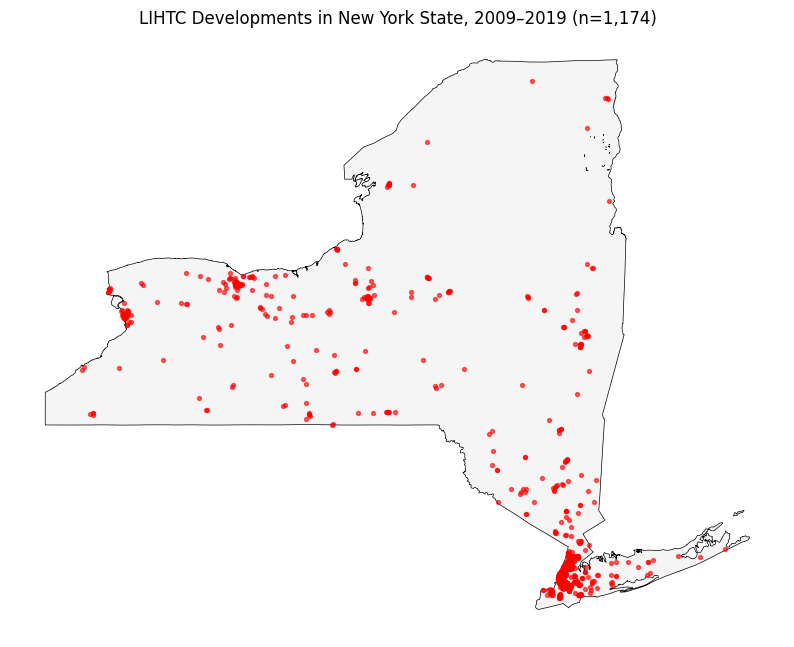

Saved: /content/drive/MyDrive/LIHTCs_and_Schools/Schools_Data/lihtc_map.png


In [ ]:
# Cell 46: Map of LIHTC developments in the sample
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Reload district shapefile if not already in memory this session
districts = gpd.read_file(
    DISTRICT_SHP
)
districts = districts.to_crs("EPSG:4326")

# Dissolve to a single NY state outline
ny_outline = districts.dissolve()

lihtc = pd.read_csv(
    LIHTC_DIR + "all_lihtc_classified.csv",
    low_memory=False
)
lihtc_gdf = gpd.GeoDataFrame(
    lihtc,
    geometry=gpd.points_from_xy(lihtc["longitude"], lihtc["latitude"]),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(10, 10))
ny_outline.plot(ax=ax, color="whitesmoke", edgecolor="black", linewidth=0.5)
lihtc_gdf.plot(ax=ax, color="red", markersize=8, alpha=0.6)

ax.set_title(f"LIHTC Developments in New York State, 2009–2019 (n={len(lihtc_gdf):,})")
ax.set_axis_off()

out_path = LIHTC_DIR + "lihtc_map.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")

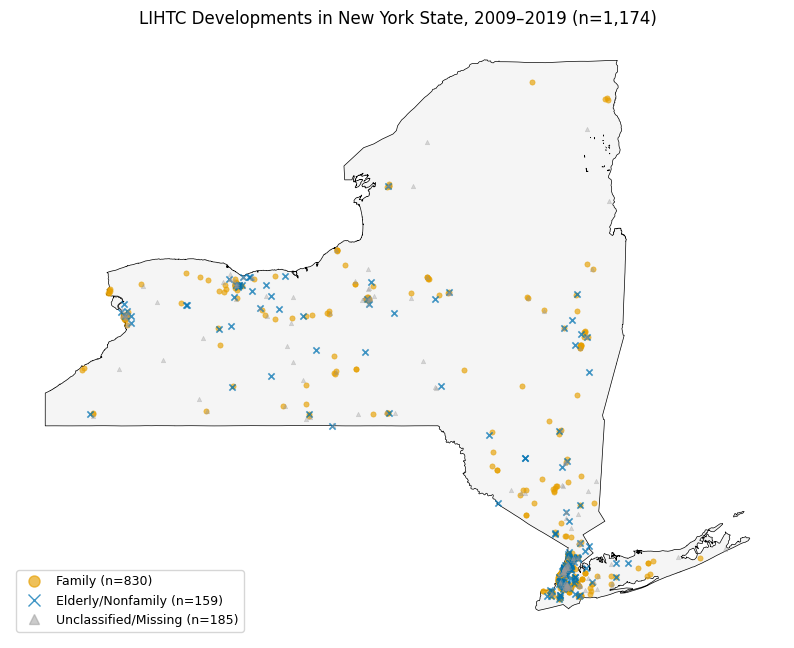

Saved: /content/drive/MyDrive/LIHTCs_and_Schools/LIHTC_Data/lihtc_map_by_type.png


In [ ]:
# Cell 47: Map of LIHTC developments, color-blind-friendly (Okabe-Ito palette + shape coding)
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd

districts = gpd.read_file(
    DISTRICT_SHP
)
districts = districts.to_crs("EPSG:4326")
ny_outline = districts.dissolve()

lihtc = pd.read_csv(
    LIHTC_DIR + "all_lihtc_classified.csv",
    low_memory=False
)
lihtc_gdf = gpd.GeoDataFrame(
    lihtc,
    geometry=gpd.points_from_xy(lihtc["longitude"], lihtc["latitude"]),
    crs="EPSG:4326"
)

style_map = {
    "family":       {"color": "#E69F00", "marker": "o", "size": 14, "alpha": 0.65},
    "nonfamily":    {"color": "#0072B2", "marker": "x", "size": 20, "alpha": 0.75},
    "unclassified": {"color": "#999999", "marker": "^", "size": 10, "alpha": 0.35},
    "missing_data": {"color": "#999999", "marker": "^", "size": 10, "alpha": 0.35},
}

fig, ax = plt.subplots(figsize=(10, 10))
ny_outline.plot(ax=ax, color="whitesmoke", edgecolor="black", linewidth=0.5)

for cls, style in style_map.items():
    subset = lihtc_gdf[lihtc_gdf["family_class"] == cls]
    if len(subset) == 0:
        continue
    ax.scatter(
        subset.geometry.x, subset.geometry.y,
        c=style["color"], marker=style["marker"], s=style["size"], alpha=style["alpha"],
        linewidths=1.2 if style["marker"] == "x" else 0.5,
    )

ax.set_title(f"LIHTC Developments in New York State, 2009–2019 (n={len(lihtc_gdf):,})")
ax.set_axis_off()

legend_elements = [
    mlines.Line2D([], [], color="#E69F00", marker="o", linestyle="None", markersize=8, alpha=0.65,
                  label=f"Family (n={(lihtc['family_class']=='family').sum()})"),
    mlines.Line2D([], [], color="#0072B2", marker="x", linestyle="None", markersize=8, alpha=0.75,
                  label=f"Elderly/Nonfamily (n={(lihtc['family_class']=='nonfamily').sum()})"),
    mlines.Line2D([], [], color="#999999", marker="^", linestyle="None", markersize=7, alpha=0.5,
                  label=f"Unclassified/Missing (n={((lihtc['family_class']=='unclassified')|(lihtc['family_class']=='missing_data')).sum()})"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=9)

out_path = LIHTC_DIR + "lihtc_map_by_type.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")

In [ ]:
#cell 48: Summary Statistics

import pandas as pd
import numpy as np

base_dir = BASE_DIR

# ---- Load sources ----
score_df = pd.read_csv(
    base_dir + "Schools_Data/Subgroups/no_nyc_subgroup_1_All_Students_collapsed.csv",
    low_memory=False
)

exposure_full_panel = pd.read_csv(
    base_dir + "Schools_Data/panel_with_exposure_no_nyc.csv",
    low_memory=False
)
exposure_cols = ["COUNT_OPEN_PIS_ALL", "COUNT_OPEN_PIS_FAMILY", "COUNT_OPEN_PIS_ELDERLY"]
exposure_school_year = (
    exposure_full_panel[["BEDSCODE", "YEAR"] + exposure_cols]
    .drop_duplicates(subset=["BEDSCODE", "YEAR"])
)
exposure_school_year = exposure_school_year[exposure_school_year["YEAR"].between(2013, 2017)]

matches_no_nyc = pd.read_csv(base_dir + "LIHTC_Data/matches_no_nyc.csv", low_memory=False)
all_lihtc = pd.read_csv(base_dir + "LIHTC_Data/all_lihtc_classified.csv", low_memory=False)


# ---- Counts (printed, not assumed) ----
n_schools_no_nyc = score_df["BEDSCODE"].nunique()
n_lihtc_total = all_lihtc["hud_id"].nunique()
n_lihtc_matched_no_nyc = matches_no_nyc["hud_id"].nunique()

print(f"Unique schools (no-NYC, all-students panel): {n_schools_no_nyc:,}")
print(f"Unique LIHTCs, full classified universe: {n_lihtc_total:,}")
print(f"Unique LIHTCs matched to a no-NYC school (any type): {n_lihtc_matched_no_nyc:,}")


# ---- Within-school SD: demean by BEDSCODE, then take SD of residuals ----
def within_school_stats(df, col, id_col="BEDSCODE"):
    d = df[[id_col, col]].dropna()
    school_means = d.groupby(id_col)[col].transform("mean")
    demeaned = d[col] - school_means
    return {
        "mean": d[col].mean(),
        "within_sd": demeaned.std(ddof=1),
        "min": d[col].min(),
        "max": d[col].max(),
        "n": len(d),
    }

score_stats = within_school_stats(score_df, "mean_scale_score_weighted")
exposure_stats = {c: within_school_stats(exposure_school_year, c) for c in exposure_cols}


# ---- Load headcount panel, compute K-12 enrollment stats ----
headcount_df = pd.read_csv(
    base_dir + "Schools_Data/Enrollment/headcount_panel_no_nyc.csv",
    low_memory=False
)
headcount_df = headcount_df[headcount_df["YEAR"].between(2013, 2019)]

enrollment_stats = within_school_stats(headcount_df, "K12_TOTAL")
print("K-12 Enrollment:", enrollment_stats)
print("\nMean Scale Score:", score_stats)
for c in exposure_cols:
    print(c, exposure_stats[c])

Unique schools (no-NYC, all-students panel): 2,300
Unique LIHTCs, full classified universe: 1,174
Unique LIHTCs matched to a no-NYC school (any type): 415
K-12 Enrollment: {'mean': np.float64(479.78391177020376), 'within_sd': 39.46936664392195, 'min': 0, 'max': 2583, 'n': 16049}

Mean Scale Score: {'mean': np.float64(302.365179378438), 'within_sd': 4.202713077713737, 'min': 216.0, 'max': 351.53053435114504, 'n': 11123}
COUNT_OPEN_PIS_ALL {'mean': np.float64(0.04573415351698315), 'within_sd': 0.12444599055376301, 'min': 0.0, 'max': 4.0, 'n': 11217}
COUNT_OPEN_PIS_FAMILY {'mean': np.float64(0.019880538468396183), 'within_sd': 0.08925412116819256, 'min': 0.0, 'max': 4.0, 'n': 11217}
COUNT_OPEN_PIS_ELDERLY {'mean': np.float64(0.00775608451457609), 'within_sd': 0.05820667589205106, 'min': 0.0, 'max': 2.0, 'n': 11217}


In [ ]:
# Cell 49: Build summary statistics LaTeX table
def fmt(x, decimals=3):
    return f"{x:,.{decimals}f}"

# ---- Rebuild summary statistics LaTeX table with enrollment row added ----
rows = [
    ("Mean Scale Score", score_stats),
    ("K-12 Enrollment", enrollment_stats),
    ("LIHTC Exposures (All)", exposure_stats["COUNT_OPEN_PIS_ALL"]),
    ("LIHTC Exposures (Family)", exposure_stats["COUNT_OPEN_PIS_FAMILY"]),
    ("LIHTC Exposures (Non-Family)", exposure_stats["COUNT_OPEN_PIS_ELDERLY"]),
]

table_lines = [
    r"\begin{table}[!htbp]",
    r"\caption{Summary Statistics}",
    r"\label{tab:summary_stats}",
    r"\centering",
    r"\begin{tabular}{lccccc}",
    r"\toprule",
    r"Variable & Mean & Within-School SD & Min & Max & $N$ \\",
    r"\midrule",
]
for label, s in rows:
    table_lines.append(
        f"{label} & {fmt(s['mean'])} & {fmt(s['within_sd'])} & {fmt(s['min'])} & {fmt(s['max'])} & {int(s['n']):,} \\\\"
    )
table_lines += [
    r"\bottomrule",
    r"\end{tabular}",
    r"\vspace{0.6em}",
    r"\parbox{0.9\linewidth}{\footnotesize",
    r"\emph{Notes:} Summary statistics for the school-year panel, no-NYC sample. "
    r"Test score (All Students subgroup) and LIHTC exposure variables cover 2013--2017; "
    r"K-12 enrollment covers 2013--2019. Within-school SD is the standard deviation of each variable "
    r"after removing school means, reflecting the variation identified under school fixed effects. "
    r"Exposure variables count nearby LIHTC developments by type.}",
    r"\end{table}",
]

summary_tex = "\n".join(table_lines)
print(summary_tex)

with open(base_dir + "Schools_Data/summary_stats_no_nyc.tex", "w") as f:
    f.write(summary_tex)
print("\nSaved: summary_stats_no_nyc.tex")

\begin{table}[!htbp]
\caption{Summary Statistics}
\label{tab:summary_stats}
\centering
\begin{tabular}{lccccc}
\toprule
Variable & Mean & Within-School SD & Min & Max & $N$ \\
\midrule
Mean Scale Score & 302.365 & 4.203 & 216.000 & 351.531 & 11,123 \\
K-12 Enrollment & 479.784 & 39.469 & 0.000 & 2,583.000 & 16,049 \\
LIHTC Exposures (All) & 0.046 & 0.124 & 0.000 & 4.000 & 11,217 \\
LIHTC Exposures (Family) & 0.020 & 0.089 & 0.000 & 4.000 & 11,217 \\
LIHTC Exposures (Non-Family) & 0.008 & 0.058 & 0.000 & 2.000 & 11,217 \\
\bottomrule
\end{tabular}
\vspace{0.6em}
\parbox{0.9\linewidth}{\footnotesize
\emph{Notes:} Summary statistics for the school-year panel, no-NYC sample. Test score (All Students subgroup) and LIHTC exposure variables cover 2013--2017; K-12 enrollment covers 2013--2019. Within-school SD is the standard deviation of each variable after removing school means, reflecting the variation identified under school fixed effects. Exposure variables count nearby LIHTC developments

In [ ]:
#Cell 50: Diagnosing the zero enrollment min

zero_rows = headcount_df[headcount_df["K12_TOTAL"] == 0]
print(f"School-years with K12_TOTAL == 0: {len(zero_rows)}")
print(zero_rows[["BEDSCODE", "YEAR", "K12_TOTAL"]].to_string())

# For each affected school, pull its full enrollment trajectory across all years
# -- a genuine opening/closing school should show a clean ramp up/down around
# the zero; an artifact will look like a gap in an otherwise-normal trend
affected_schools = zero_rows["BEDSCODE"].unique()

full_history = headcount_df[headcount_df["BEDSCODE"].isin(affected_schools)].sort_values(["BEDSCODE", "YEAR"])
print("\nFull enrollment trajectory for affected school(s):")
print(full_history[["BEDSCODE", "YEAR", "K12_TOTAL"]].to_string())

# Also check whether the raw grade-level columns are ALL zero/missing for
# that row, or whether K12_TOTAL==0 came from summing a mix of NaNs that
# got silently treated as 0 during the Step 8 collapse
grade_cols = [c for c in headcount_df.columns if c.isdigit() or c == "KFULL"]
print("\nGrade-level columns for the zero row(s):")
print(zero_rows[["BEDSCODE", "YEAR"] + grade_cols].to_string())

School-years with K12_TOTAL == 0: 2
          BEDSCODE  YEAR  K12_TOTAL
1291  140600010042  2018          0
1292  140600010042  2019          0

Full enrollment trajectory for affected school(s):
          BEDSCODE  YEAR  K12_TOTAL
1286  140600010042  2013         27
1287  140600010042  2014         18
1288  140600010042  2015         10
1289  140600010042  2016          2
1290  140600010042  2017          3
1291  140600010042  2018          0
1292  140600010042  2019          0

Grade-level columns for the zero row(s):
          BEDSCODE  YEAR  KFULL  1  2  3  4  5  6  7  8  9  10  11  12
1291  140600010042  2018      0  0  0  0  0  0  0  0  0  0   0   0   0
1292  140600010042  2019      0  0  0  0  0  0  0  0  0  0   0   0   0


In [ ]:
#Cell 51: Identifying the school that zeroed out

import pandas as pd

base_dir = BASE_DIR
target_beds = "140600010042"

# School identity, read fresh from the Step 4 output
schools_ref = pd.read_csv(base_dir + "Schools_Data/schools_with_district_codes.csv", low_memory=False)
schools_ref["BEDSCODE"] = schools_ref["BEDSCODE"].astype(str)

school_detail = schools_ref[schools_ref["BEDSCODE"] == target_beds][
    ["BEDSCODE", "NAME", "COUNTY_DESC", "SCHOOLDIST", "NRC_CODE"]
].drop_duplicates()

print("School identity:")
print(school_detail.to_string())

# Full enrollment trajectory, read fresh
headcount_df = pd.read_csv(base_dir + "Schools_Data/Enrollment/headcount_panel_no_nyc.csv", low_memory=False)
headcount_df["BEDSCODE"] = headcount_df["BEDSCODE"].astype(str)

print("\nFull enrollment trajectory:")
print(
    headcount_df[headcount_df["BEDSCODE"] == target_beds][
        ["YEAR", "K12_TOTAL"]
    ].sort_values("YEAR").to_string(index=False)
)

# LIHTC exposure history, read fresh
exposure_df = pd.read_csv(base_dir + "Schools_Data/panel_with_exposure_no_nyc.csv", low_memory=False)
exposure_df["BEDSCODE"] = exposure_df["BEDSCODE"].astype(str)

print("\nLIHTC exposure history for this school:")
print(
    exposure_df[exposure_df["BEDSCODE"] == target_beds][
        ["YEAR", "COUNT_OPEN_PIS_ALL", "COUNT_OPEN_PIS_FAMILY", "COUNT_OPEN_PIS_ELDERLY"]
    ].sort_values("YEAR").to_string(index=False)
)

KeyboardInterrupt: 

In [ ]:
# Cell 52: Distance table
KM_TO_MILES = 0.621371

type_labels = {"ALL": "All", "FAMILY": "Family", "ELDERLY": "Non-Family"}
order = ["ALL", "FAMILY", "ELDERLY"]

dist_rows = []
for t in order:
    sub = (matches_no_nyc.loc[matches_no_nyc["lihtc_type"] == t, "distance_km"].dropna() * KM_TO_MILES)
    dist_rows.append({
        "label": type_labels[t],
        "mean": sub.mean(),
        "p25": sub.quantile(0.25),
        "median": sub.quantile(0.50),
        "p75": sub.quantile(0.75),
        "n": len(sub),
    })

dist_lines = [
    r"\begin{table}[!htbp]",
    r"\caption{Distance from Schools to Matched LIHTC Developments}",
    r"\label{tab:distances}",
    r"\centering",
    r"\begin{tabular}{llccccc}",
    r"\toprule",
    r"LIHTC Type & Mean (mi) & P25 & Median & P75 & N \\",
    r"\midrule",
]
for r in dist_rows:
    dist_lines.append(
        f"{r['label']} & {fmt(r['mean'])} & {fmt(r['p25'])} & {fmt(r['median'])} & {fmt(r['p75'])} & {int(r['n']):,} \\\\"
    )
dist_lines += [
    r"\bottomrule",
    r"\end{tabular}",
    r"\vspace{0.6em}",
    r"\parbox{0.9\linewidth}{\footnotesize",
    r"\emph{Notes:} Distances in miles from each matched school to its nearest LIHTC development, by development type "
    r"(no-NYC sample). Statistics are computed across all matched school-LIHTC pairs.}",
    r"\end{table}",
]

distance_tex = "\n".join(dist_lines)
print(distance_tex)

with open(base_dir + "Schools_Data/distance_table_no_nyc.tex", "w") as f:
    f.write(distance_tex)
print("\nSaved: distance_table_no_nyc.tex")

\begin{table}[!htbp]
\caption{Distance from Schools to Matched LIHTC Developments}
\label{tab:distances}
\centering
\begin{tabular}{llccccc}
\toprule
LIHTC Type & Mean (mi) & P25 & Median & P75 & N \\
\midrule
All & 0.772 & 0.263 & 0.499 & 0.853 & 415 \\
Family & 0.831 & 0.265 & 0.506 & 0.829 & 214 \\
Non-Family & 0.793 & 0.254 & 0.556 & 0.926 & 81 \\
\bottomrule
\end{tabular}
\vspace{0.6em}
\parbox{0.9\linewidth}{\footnotesize
\emph{Notes:} Distances in miles from each matched school to its nearest LIHTC development, by development type (no-NYC sample). Statistics are computed across all matched school-LIHTC pairs.}
\end{table}

Saved: distance_table_no_nyc.tex


In [ ]:
check = headcount_no_nyc[headcount_no_nyc["BEDSCODE"] == "500201060009"].sort_values("YEAR")
print(check[["YEAR", "K12_TOTAL"]].to_string(index=False))

 YEAR  K12_TOTAL
 2013       2494
 2014       2517
 2015       2571
 2016       2524
 2017       2519
 2018       2583
 2019       2559
